# Evaluate label transfer

In [4]:
from pathlib import Path
import os
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import sparse
import warnings
import session_info
import sys

In [14]:
plt.rcParams['figure.figsize'] = (3, 3)
plt.rcParams['figure.dpi'] = 150

warnings.simplefilter(action='ignore', category=FutureWarning)

### Setup

In [9]:
base_dir = Path("/home/workspace/projects/drg")
#base_dir = Path("/home/workspace/temp/madv2/")

input_dir = os.path.join(base_dir, 'h5ad/export_03/')

### Read and process adata

In [10]:
adata = sc.read_h5ad(os.path.join(input_dir, 'adata-scvi-leiden.h5ad'))
adata

AnnData object with n_obs × n_vars = 93854 × 480
    obs: 'cell_id', 'x_centroid', 'y_centroid', 'transcript_counts', 'control_probe_counts', 'genomic_control_counts', 'control_codeword_counts', 'unassigned_codeword_counts', 'deprecated_codeword_counts', 'total_counts', 'cell_area', 'nucleus_area', 'nucleus_count', 'segmentation_method', 'output_id', 'xenium_run_id', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'log1p_total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_20_genes', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_150_genes', 'doublet_scores', 'predicted_doublets', 'batch', 'slide', '_scvi_batch', '_scvi_labels', 'leiden_scVI_1'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden_scVI_1', 'leiden_scVI_1_colors', 'log1p', 'neighbors', 'output_id_colors', 'rank_genes_groups', 'umap'
    obsm: 'X_scVI', 'X_umap', 'spatial'
    layers: 'counts', 'log1p', 'normalized_1e6'
    obsp: 'connectivities', 'distances'

## Compare to Leiden clusters

In [11]:
#sc.pl.umap(adata, color = ['Epcam', 'Ptprc', 'Acta2', 'Col1a1'])

In [12]:
#sc.pl.umap(adata, color = ['scanvi_labels_xenium'], frameon = False)

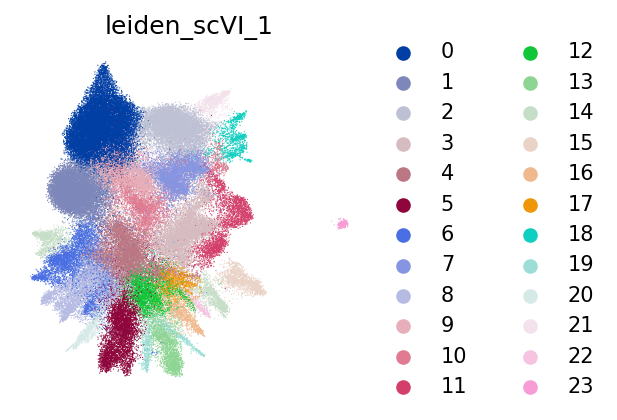

In [15]:
sc.pl.umap(adata, color = ['leiden_scVI_1'], frameon = False)

In [ ]:
sc.pl.umap(adata, color = ['total_counts','Thy1', 'Nefh', 'Syp', 'Ugt8a', 'Pecam1', 'Ptprc', 'Itgam', 'Itgax', 'Prox1'])

# Evaluate co-expression

In [8]:
adata.obs['cell_type'] = adata.obs['leiden_scVI_1'].copy()

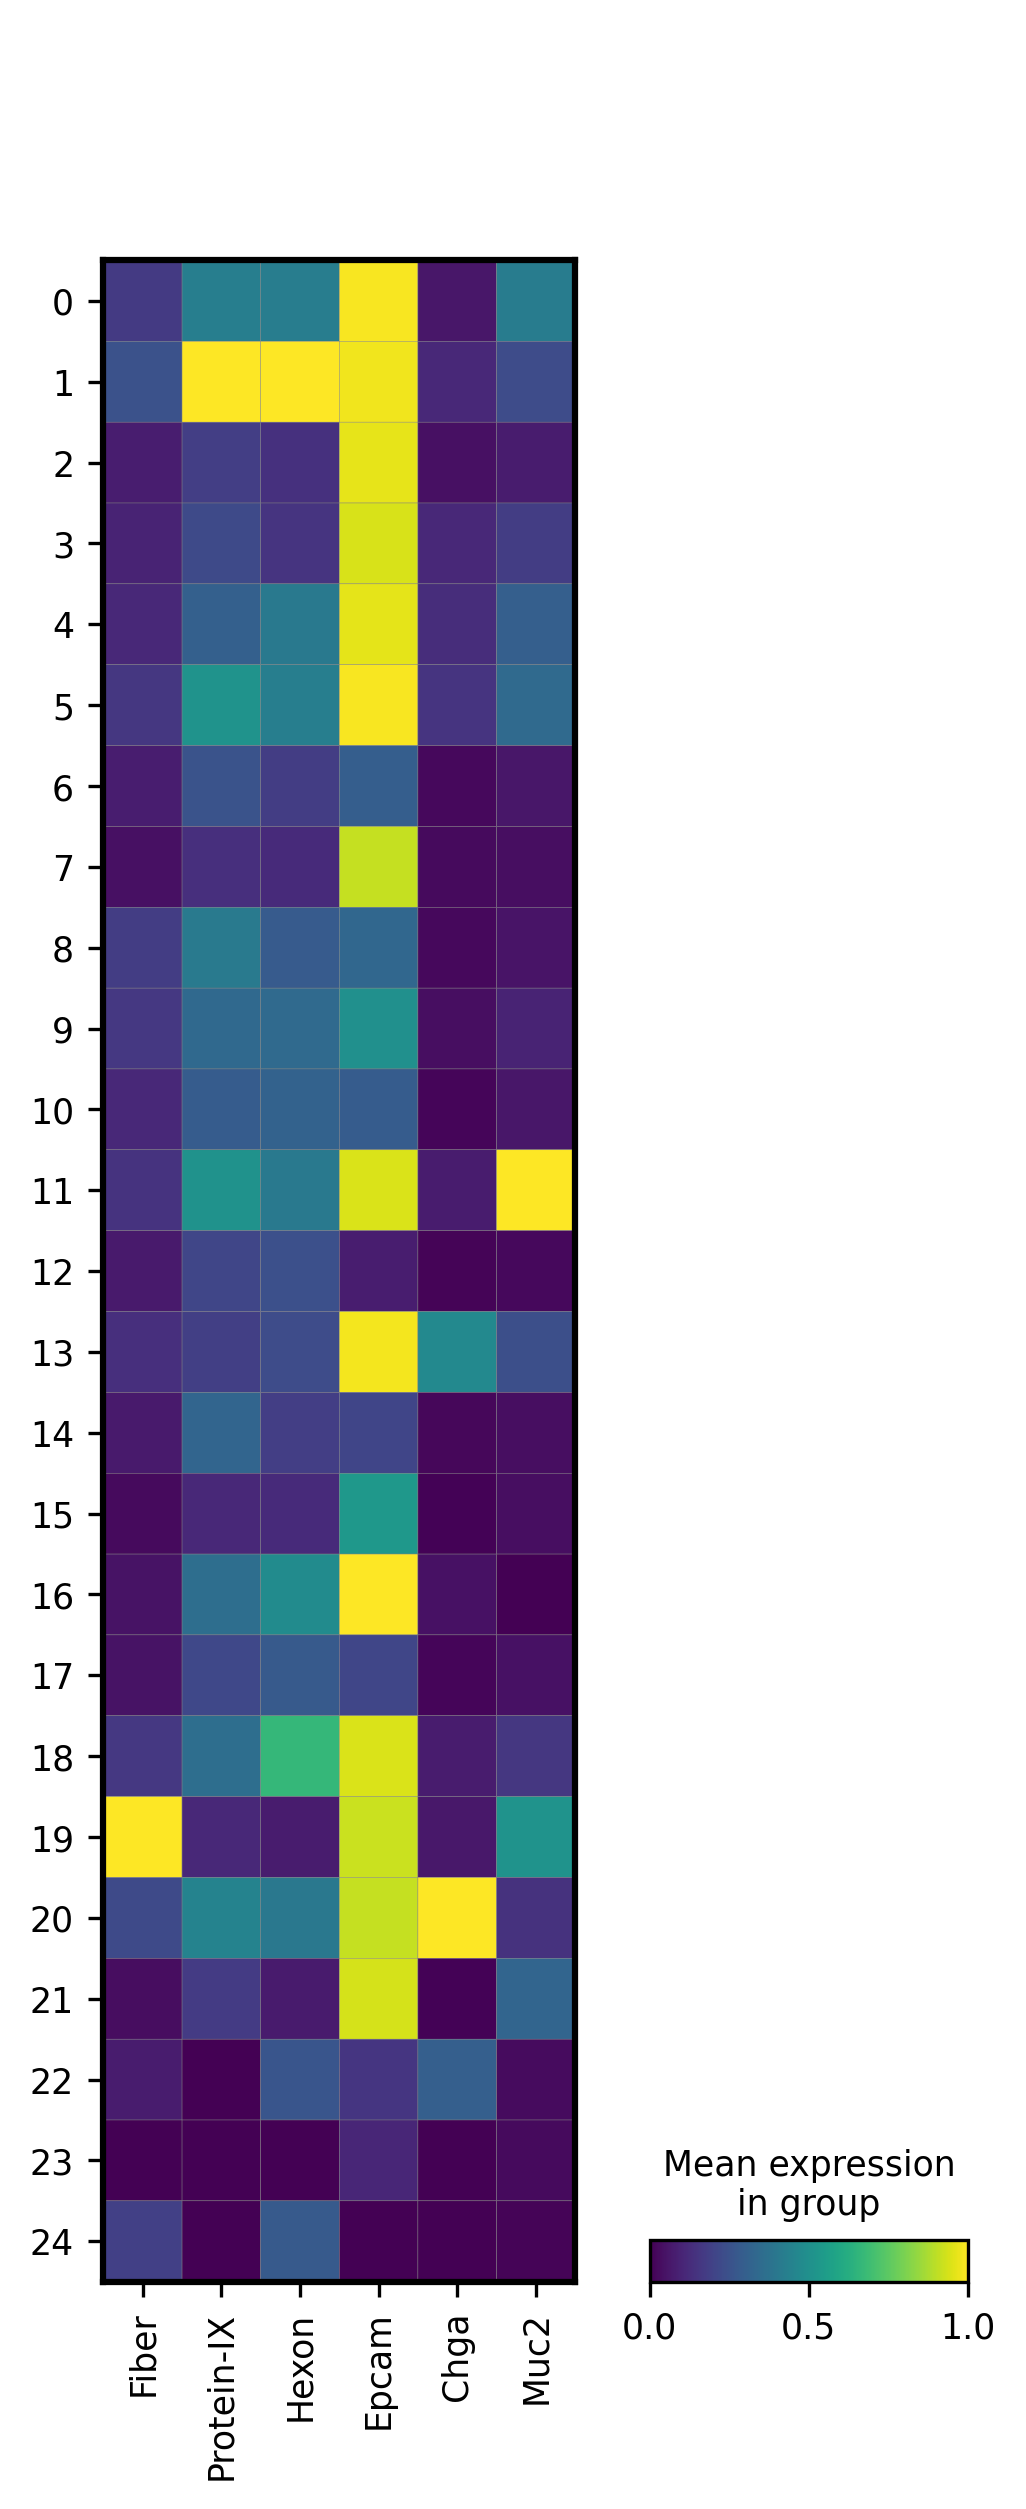

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


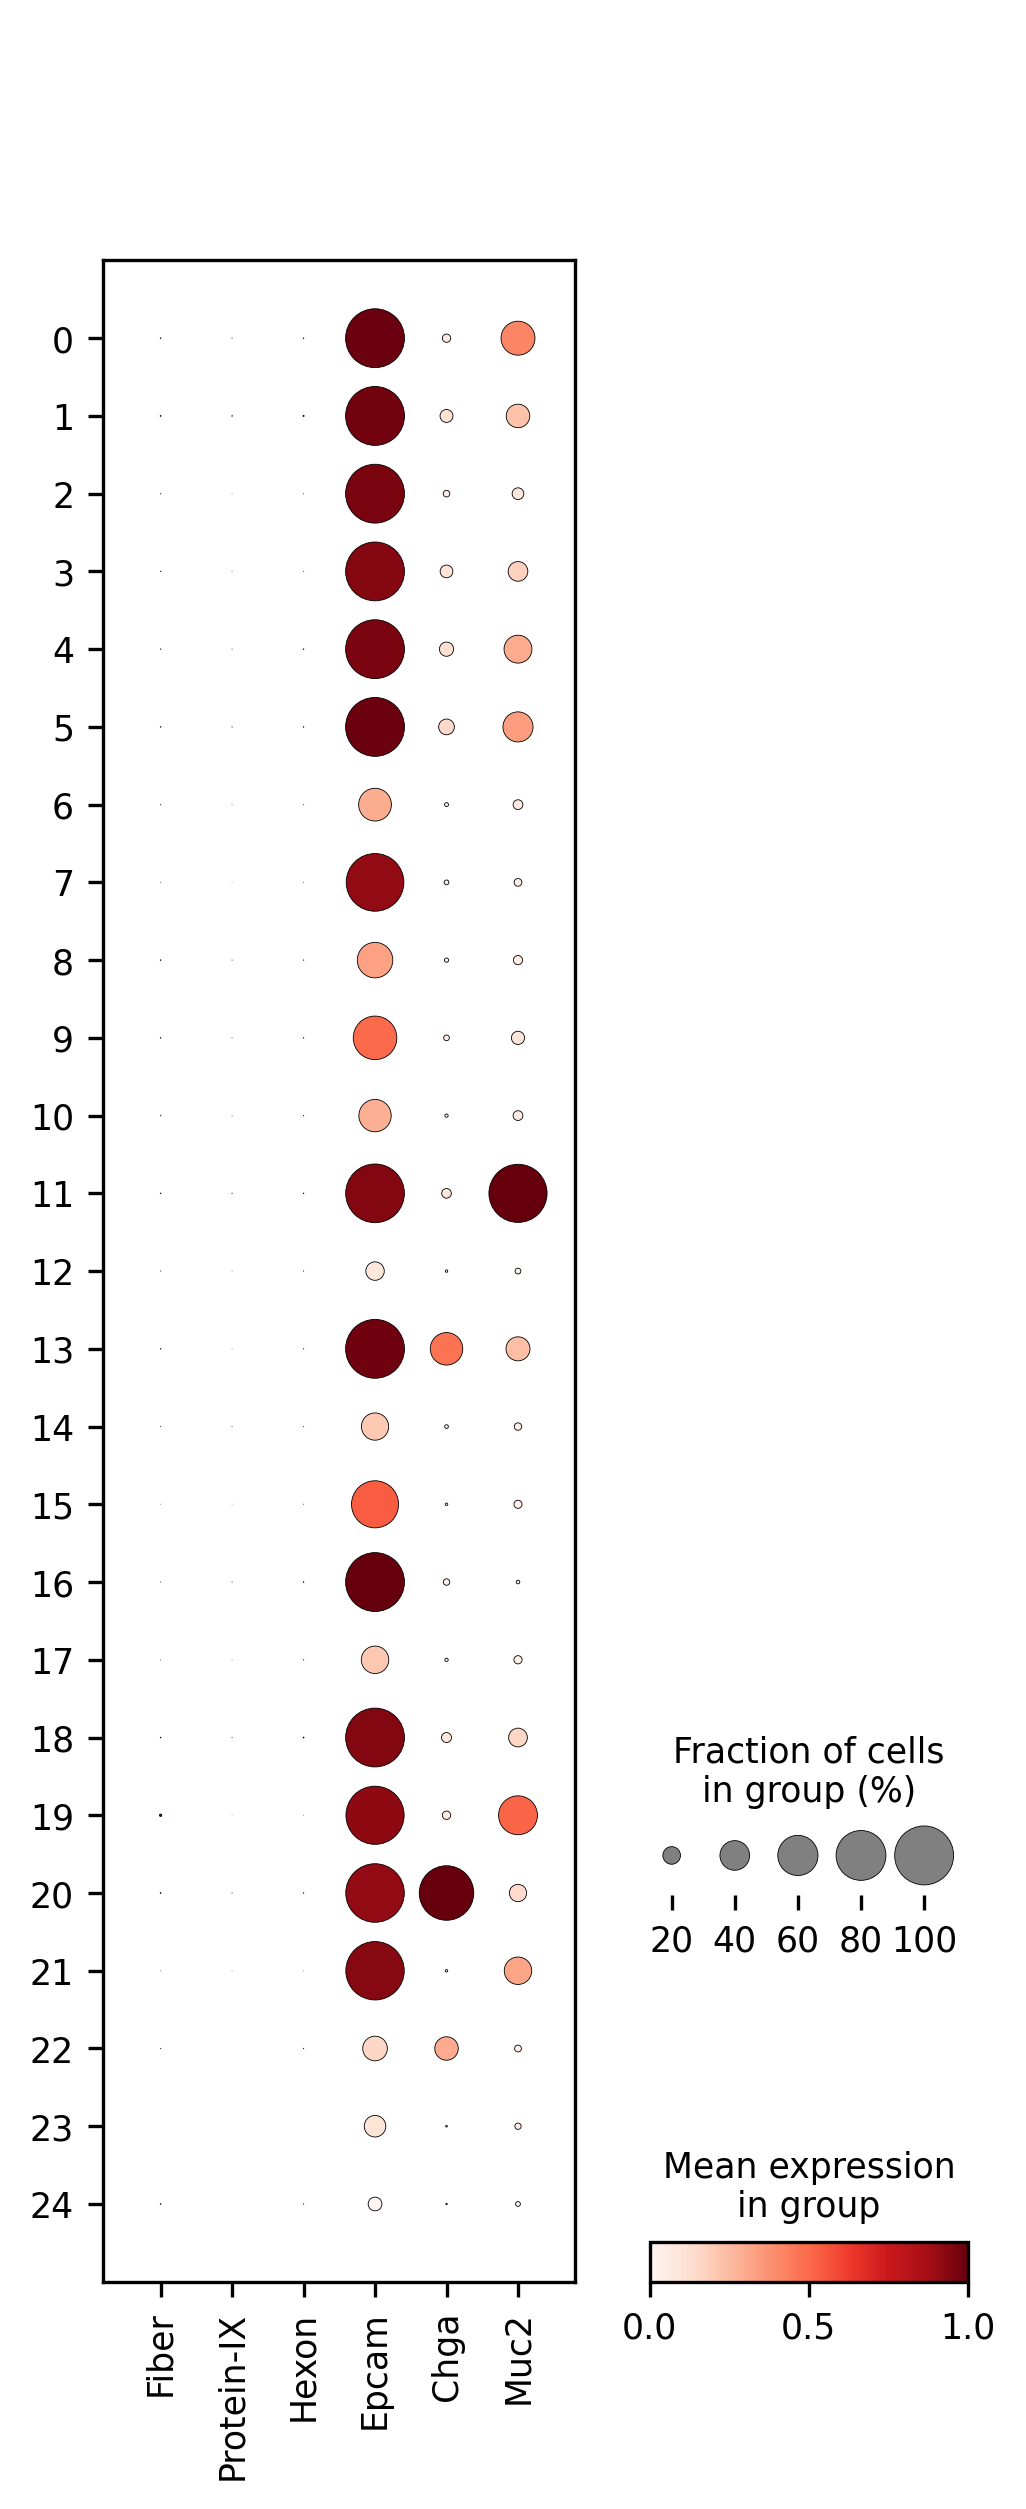

In [31]:
genes = ['Fiber', 'Protein-IX', 'Hexon', 'Epcam', 'Chga', 'Muc2']
sc.pl.matrixplot(adata, var_names = genes, groupby = 'leiden_scVI_1', standard_scale = 'var')
sc.pl.dotplot(adata, var_names = genes, groupby = 'leiden_scVI_1', standard_scale = 'var')

In [10]:
genes = ["Hexon", "Fiber", "Protein-IX"]

adata_subset = adata[:, genes]

df = pd.DataFrame(
    adata_subset.X.toarray(),  # convert sparse to dense if needed
    columns=genes,
    index=adata.obs['cell_type']
)

# Average expression per cell type
mean_expr = df.groupby(level=0).mean()

# Count cells expressing all three (simple >0 threshold)
mask = (df[genes] > 0).all(axis=1)
colocalizing_counts = df[mask].index.value_counts()

print("Mean expression per cell type:")
print(mean_expr)
print("\nNumber of cells co-expressing all three genes per cell type:")
print(colocalizing_counts)

Mean expression per cell type:
              Hexon     Fiber  Protein-IX
cell_type                                
0          0.016061  0.018574    0.006693
1          0.038272  0.027463    0.015838
2          0.005237  0.008600    0.002851
3          0.005707  0.010441    0.003532
4          0.015526  0.012054    0.004770
5          0.016272  0.016950    0.008147
6          0.006777  0.008747    0.004076
7          0.004548  0.004653    0.002138
8          0.010821  0.019364    0.006453
9          0.013133  0.017733    0.005364
10         0.011937  0.012097    0.004562
11         0.015545  0.015734    0.007985
12         0.009337  0.007273    0.003309
13         0.008707  0.014430    0.002930
14         0.007005  0.007289    0.005108
15         0.004566  0.002677    0.001791
16         0.018293  0.005285    0.005687
17         0.010723  0.005209    0.003448
18         0.025484  0.017472    0.005641
19         0.002972  0.108425    0.001772
20         0.015324  0.024450    0.007083
21 

In [11]:

genes = ["Hexon", "Fiber", "Protein-IX"]  # must match adata.var_names exactly

# Keep only genes that exist to avoid KeyErrors
present = [g for g in genes if g in adata.var_names]
if len(present) < 2:
    raise ValueError(f"Need at least 2 of {genes} in adata.var_names; found {present}")

# Subset and materialize to dense if needed
X = adata[:, present].X
if sparse.issparse(X):
    X = X.toarray()

# Build per-cell dataframe
df = pd.DataFrame(X, columns=present)
df["cell_type"] = adata.obs["cell_type"].values

# Compute, for each cell type, the mean of the upper-triangular Spearman correlations among the genes
rows = []
for ct, gdf in df.groupby("cell_type", sort=False):
    # Skip if fewer than 3 cells; correlations are unstable
    if len(gdf) < 3:
        rows.append((ct, np.nan, len(gdf)))
        continue
    corr = gdf[present].corr(method="spearman")
    # Extract upper triangle without diagonal
    mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
    vals = corr.where(mask).stack()
    score = vals.mean() if not vals.empty else np.nan
    rows.append((ct, score, len(gdf)))

# Summary table: higher score => tighter co-variation (more likely infected cell type)
scores = pd.DataFrame(rows, columns=["cell_type", "spearman_coexpr_score", "n_cells"])
scores = scores.dropna().sort_values(["spearman_coexpr_score", "n_cells"], ascending=[False, False]).reset_index(drop=True)

print(scores.head(20))  # top candidates

   cell_type  spearman_coexpr_score  n_cells
0          1               0.318862   186197
1         20               0.234515    11741
2          5               0.178592   140672
3         11               0.158417    54573
4          0               0.128203   287610
5         12               0.104402    49161
6         22               0.099553     8152
7          6               0.089439   100214
8          4               0.075810   148687
9         14               0.065679    36931
10         8               0.064536    87057
11         9               0.049459    70116
12        17               0.048742    16546
13        10               0.037817    58716
14         7               0.032449    99794
15         2               0.020113   181446
16        18               0.013798    13072
17         3               0.001625   168088
18        15              -0.000369    20634
19        21              -0.000392     8443


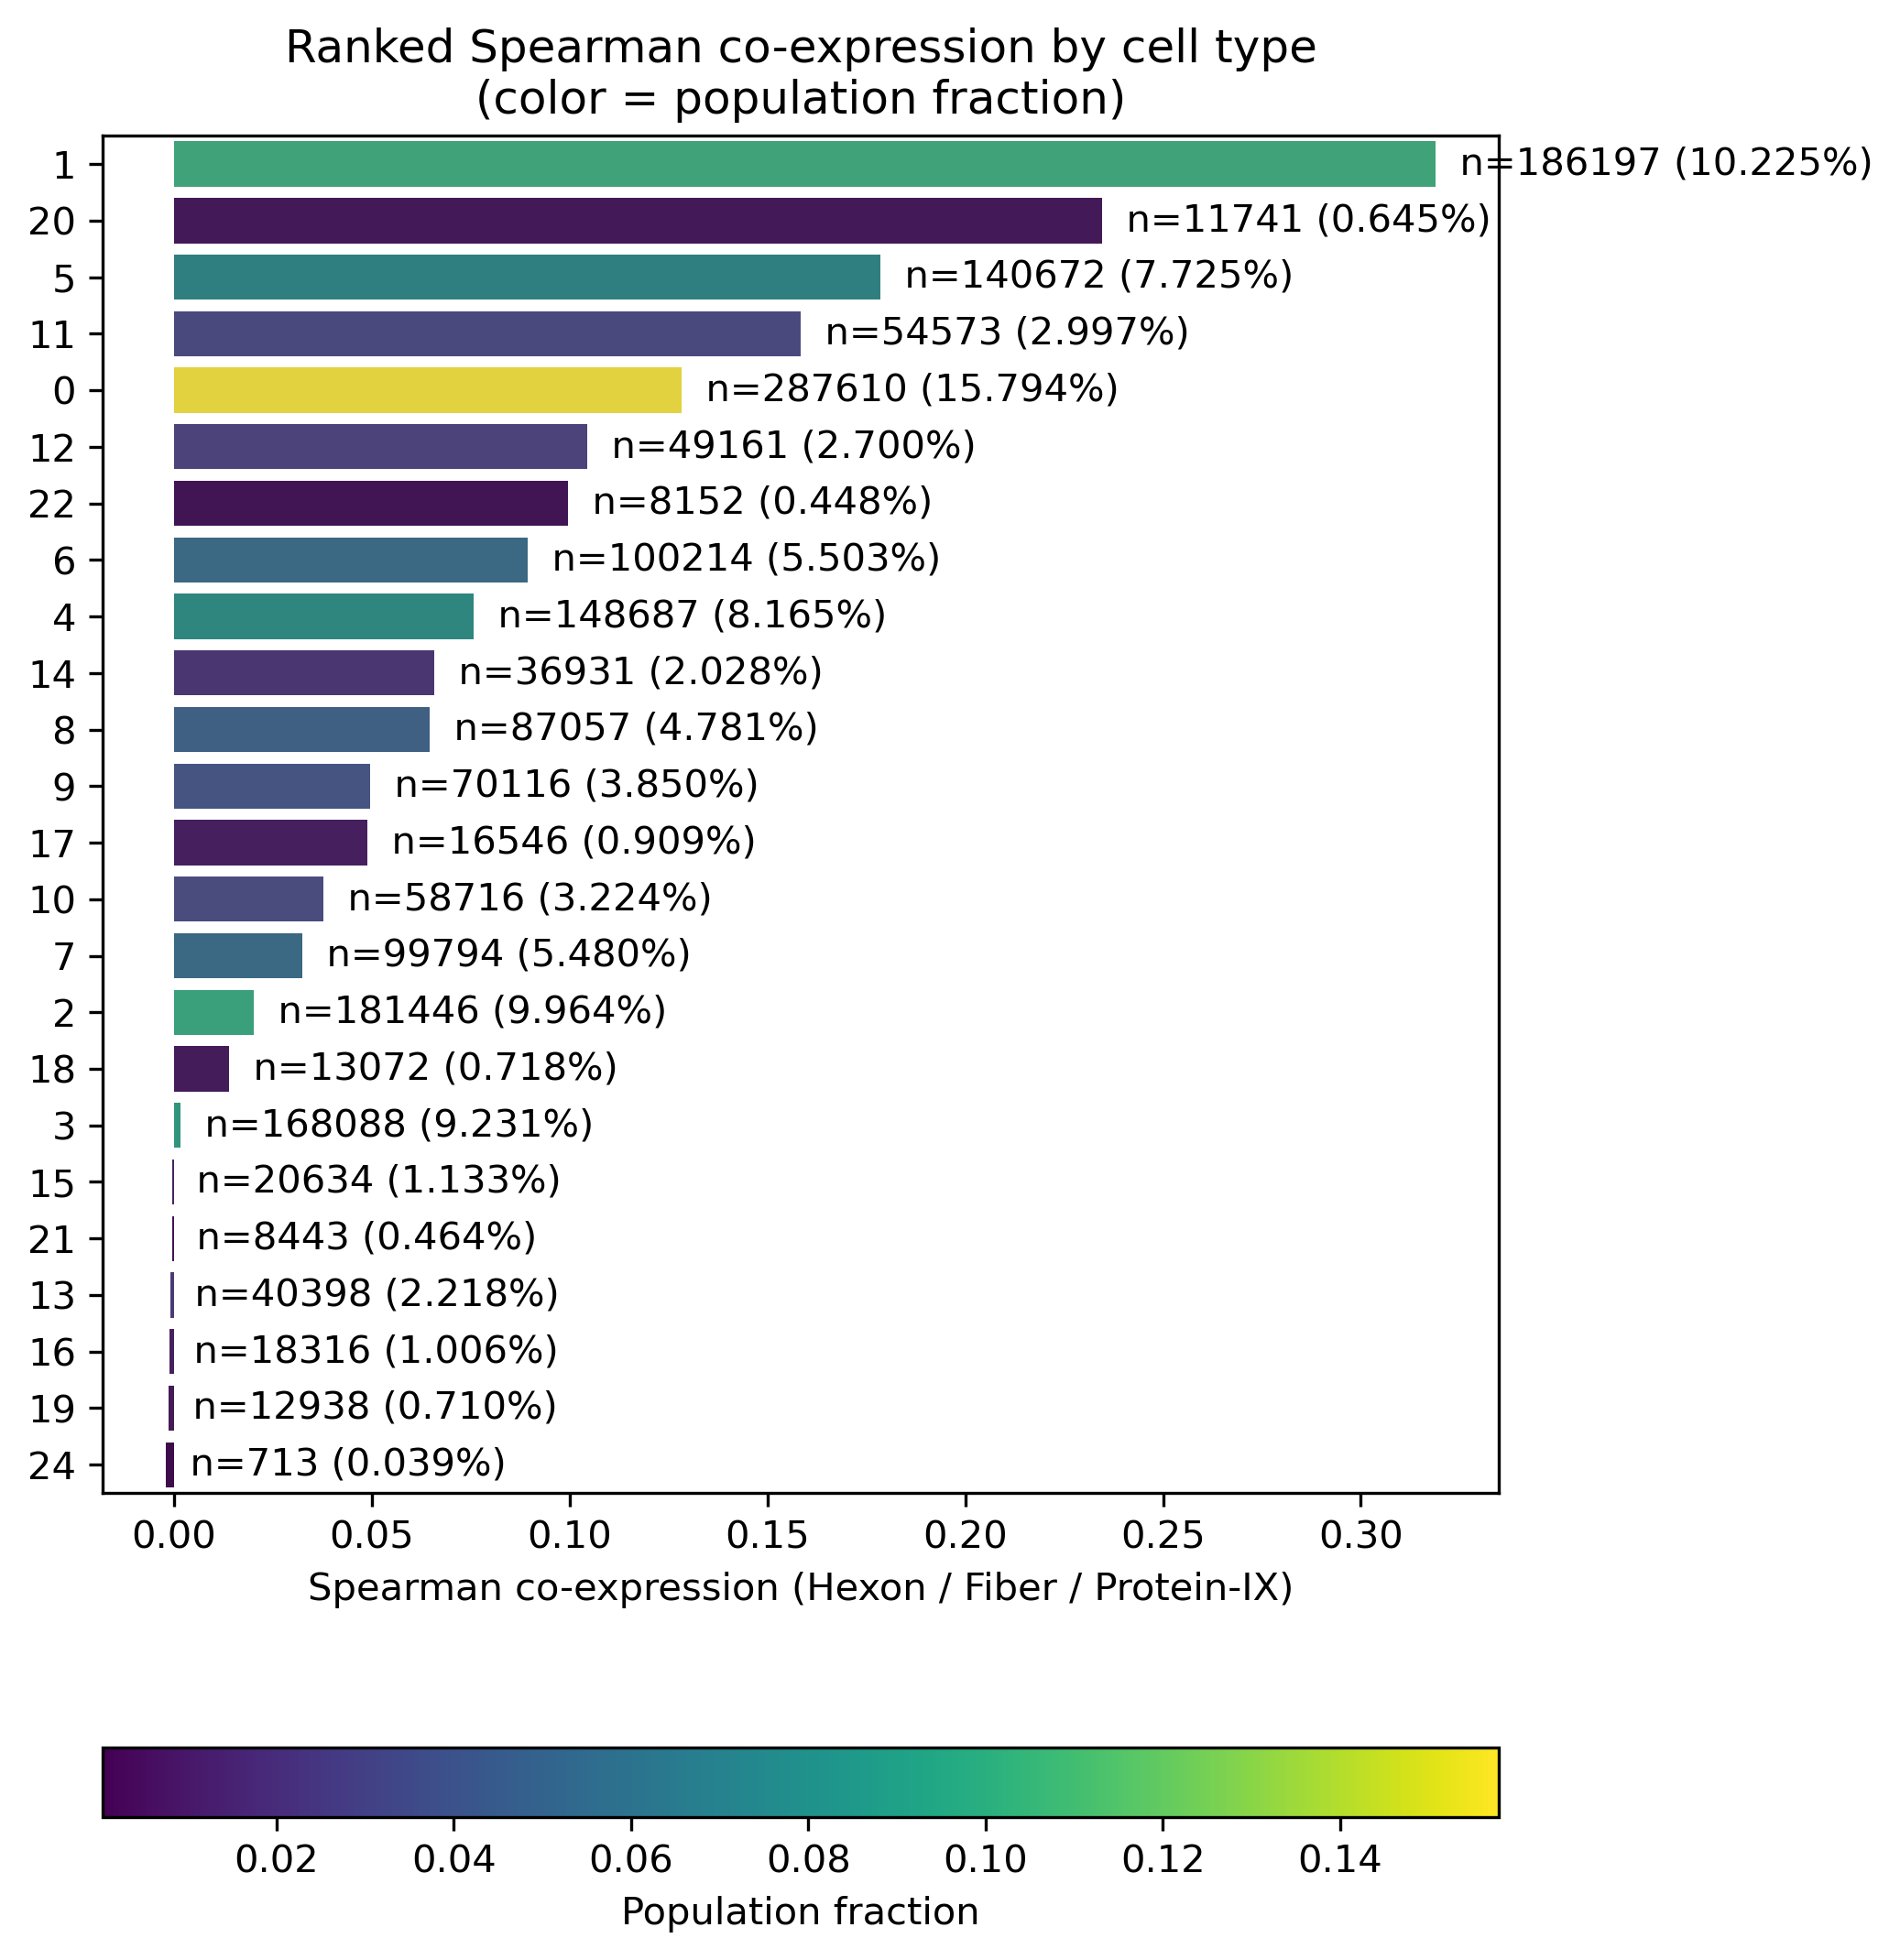

In [22]:
import matplotlib as mpl

# --- Viz: Spearman per cell type, color = population fraction ---
total_cells = df.shape[0]
scores_viz = scores.copy()
scores_viz["n_frac"] = scores_viz["n_cells"] / total_cells

scores_viz = scores_viz.sort_values("spearman_coexpr_score", ascending=False).reset_index(drop=True)

# consistent figure height
n_ct = len(scores_viz)
plt.figure(figsize=(7, 0.4*n_ct))

# continuous color mapping for n_frac
vmin = scores_viz["n_frac"].min()
vmax = scores_viz["n_frac"].max()
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.viridis
colors = [cmap(norm(v)) for v in scores_viz["n_frac"]]

ax = sns.barplot(
    data=scores_viz,
    x="spearman_coexpr_score",
    y="cell_type",
    palette=colors,
    dodge=False
)
ax.set_xlabel("Spearman co-expression (Hexon / Fiber / Protein-IX)")
ax.set_ylabel("")
ax.set_title("Ranked Spearman co-expression by cell type\n(color = population fraction)")

# annotate with n_cells and % of dataset
for i, row in scores_viz.iterrows():
    x = row["spearman_coexpr_score"]
    n = row["n_cells"]
    frac = row["n_frac"]
    plt.text(x, i, f"  n={n} ({frac:.3%})", va="center")

# add a continuous colorbar for population fraction
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation="horizontal", pad=0.15, fraction=0.05)
cbar.set_label("Population fraction")

plt.tight_layout()
plt.subplots_adjust(bottom=0.3)
plt.show()

In [14]:
# ---- Fraction infected + Spearman correlation + annotation ----

# Align df to adata indices
df.index = adata.obs_names
ct = adata.obs.loc[df.index, "cell_type"].astype(str)

# Infection mask (triple-positive)
thresh = 0
infected = (df[present] > thresh).all(axis=1)

# Numerators / denominators
n_total_by_type = ct.value_counts()
n_inf_by_type   = ct[infected].value_counts().reindex(n_total_by_type.index, fill_value=0)
frac_infected   = (n_inf_by_type / n_total_by_type).rename("frac_infected")

# --- Spearman correlation calculation per cell type ---
spearman_scores = {}
for ct_name, gdf in df.groupby(ct):
    if len(gdf) < 3:  # too few cells
        spearman_scores[ct_name] = np.nan
        continue
    corr = gdf[present].corr(method="spearman")
    # average of upper-triangle pairwise correlations
    mask = np.triu(np.ones(corr.shape, dtype=bool), k=1)
    vals = corr.where(mask).stack()
    spearman_scores[ct_name] = vals.mean() if not vals.empty else np.nan

spearman_scores = pd.Series(spearman_scores, name="spearman_coexpr_score")

# --- Merge into one tidy table ---
merged = (
    pd.concat([frac_infected, spearman_scores], axis=1)
      .reset_index()
      .rename(columns={"index": "cell_type"})
      .sort_values("frac_infected", ascending=False)
      .reset_index(drop=True)
)

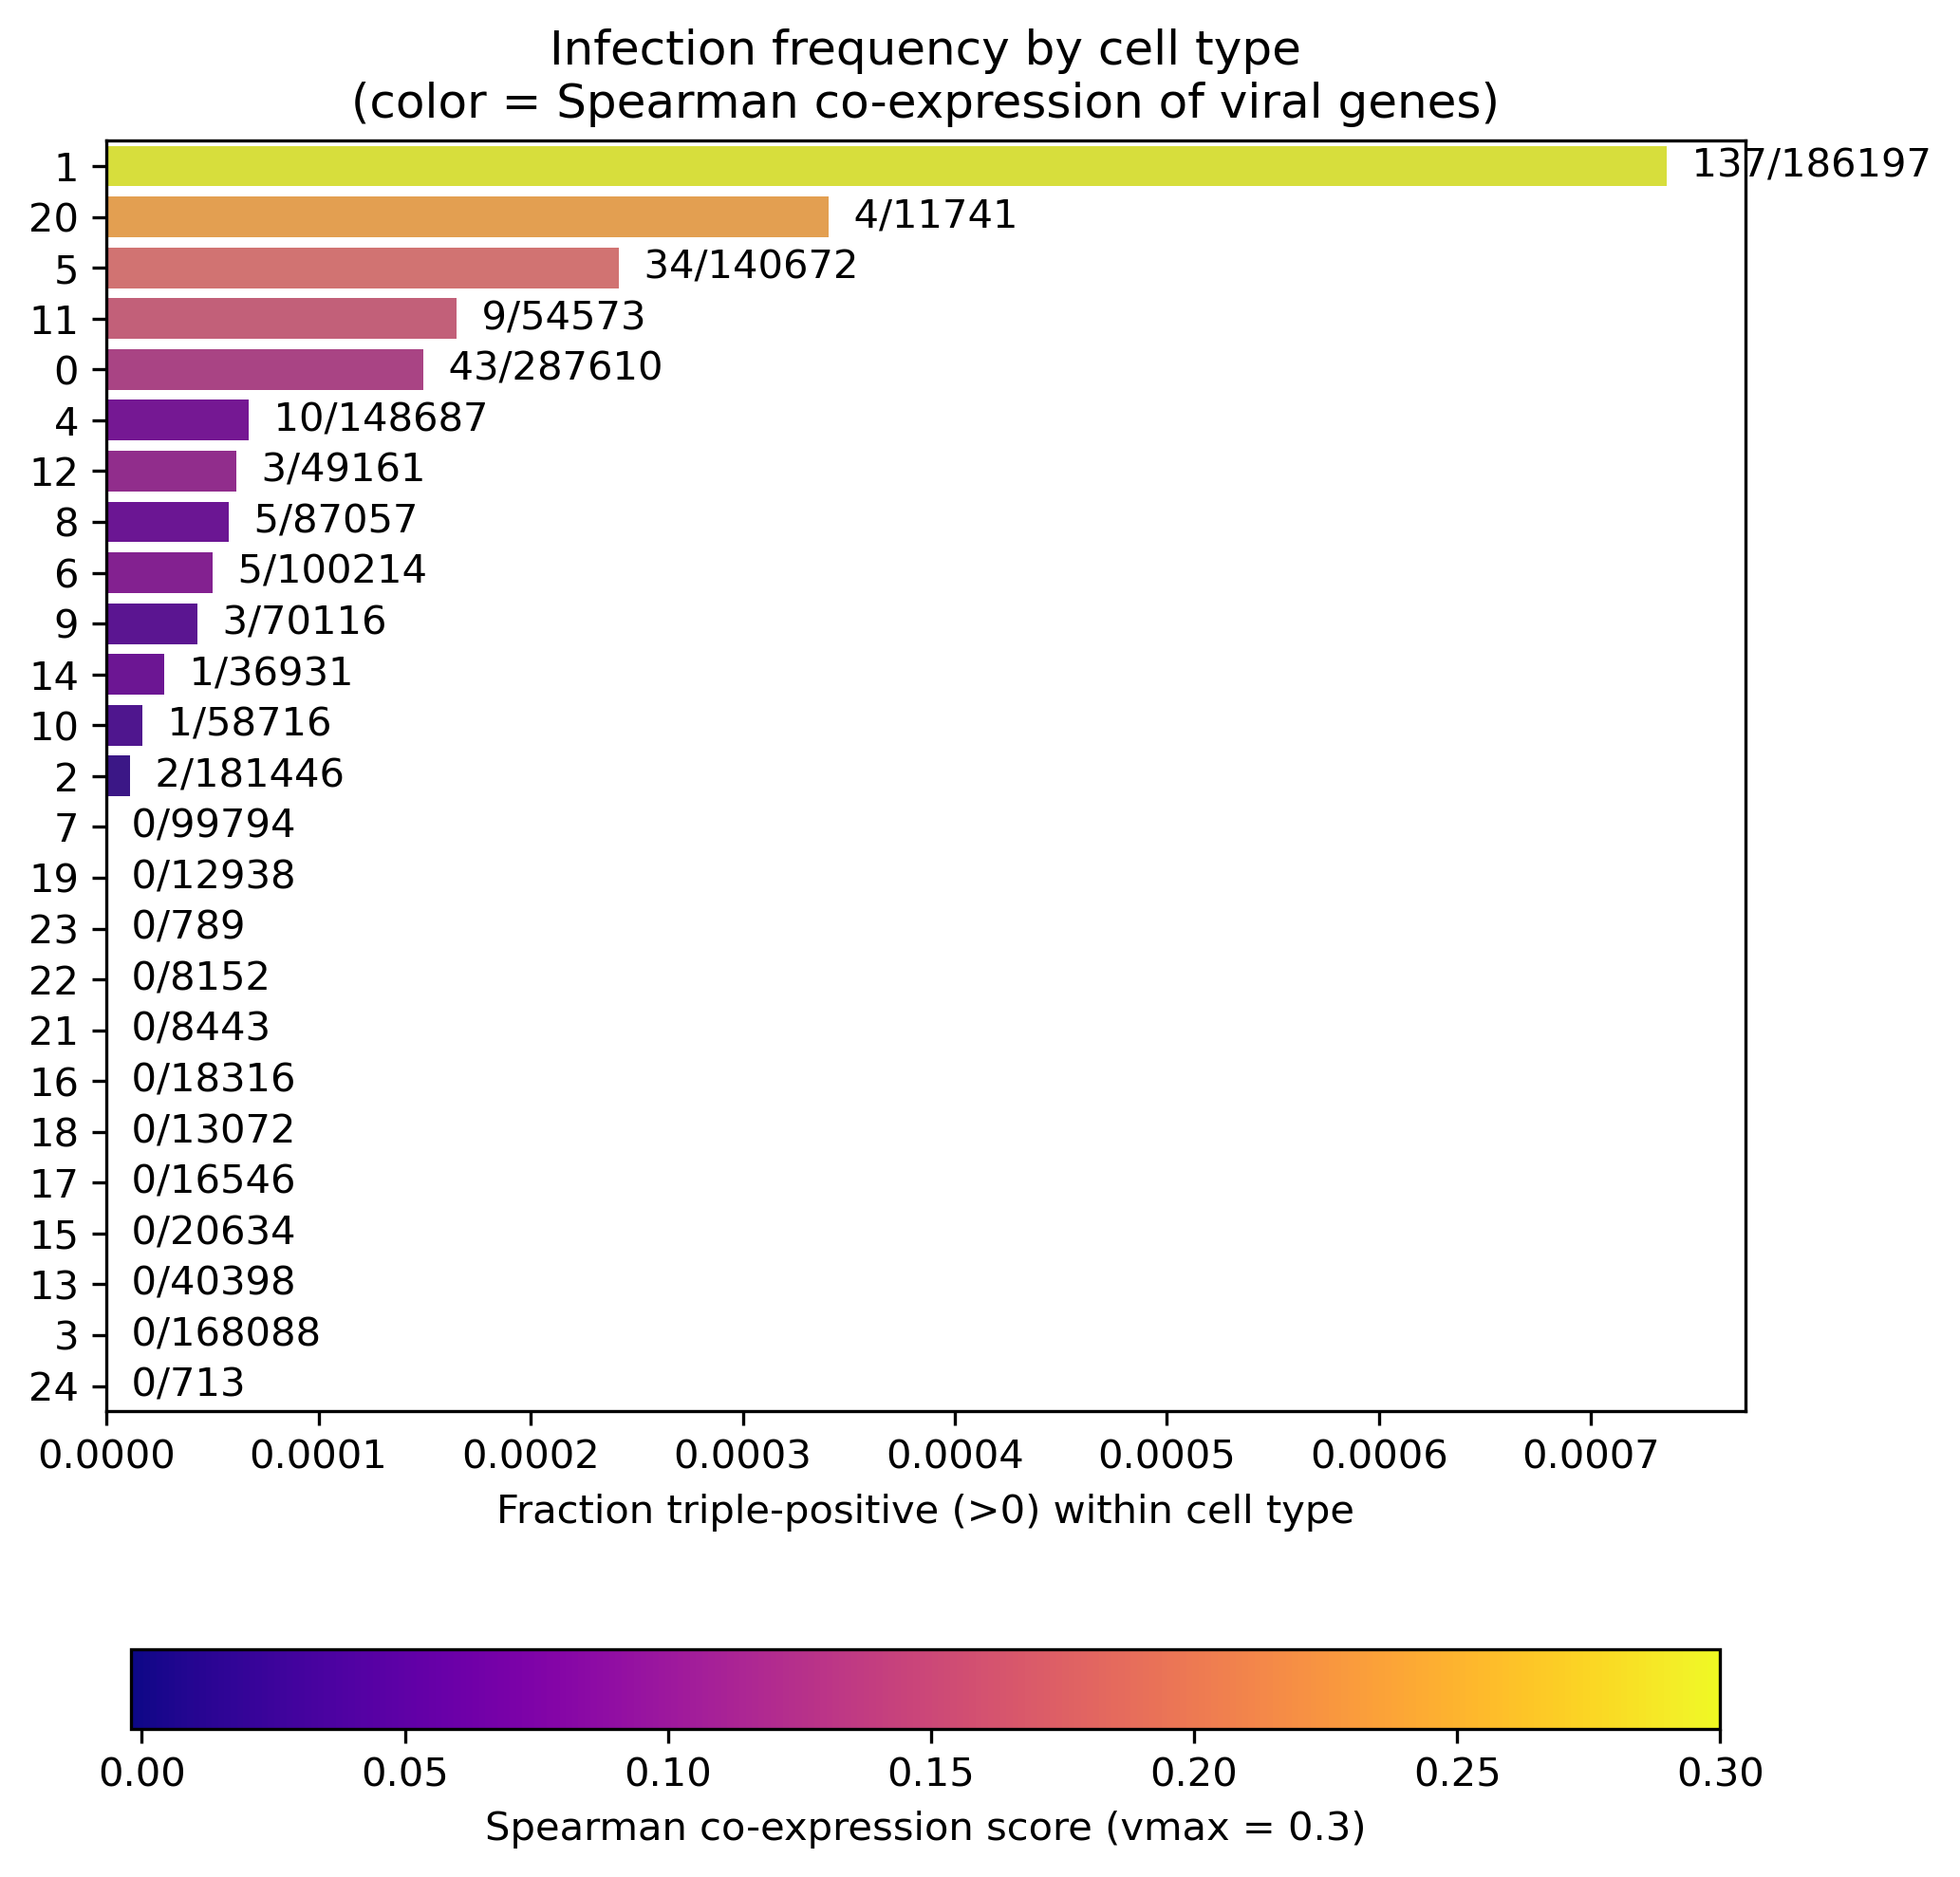

In [28]:
import matplotlib as mpl

# --- Plot: bar length = fraction infected, hue = Spearman score ---
n_ct = max(len(scores_viz), len(merged))
plt.figure(figsize=(7, 0.35*n_ct))

# cap vmax at 0.3 for better contrast
vmin = merged["spearman_coexpr_score"].min()
vmax = 0.3
norm = mpl.colors.Normalize(vmin=vmin, vmax=vmax)
cmap = plt.cm.plasma

# sort so plotting order is clear
plot_data = merged.sort_values("frac_infected", ascending=False).reset_index(drop=True)
colors = [cmap(norm(v)) for v in plot_data["spearman_coexpr_score"]]

ax = sns.barplot(
    data=plot_data,
    x="frac_infected",
    y="cell_type",
    palette=colors,
    dodge=False
)
ax.set_xlabel(f"Fraction triple-positive (>{thresh}) within cell type")
ax.set_ylabel("")
ax.set_title("Infection frequency by cell type\n(color = Spearman co-expression of viral genes)")

# annotate infected/total
for i, row in plot_data.iterrows():
    fi = row["frac_infected"]
    ni = int(n_inf_by_type.get(row["cell_type"], 0))
    nt = int(n_total_by_type.get(row["cell_type"], 0))
    plt.text(fi, i, f"  {ni}/{nt}", va="center")

# add a continuous colorbar with capped range
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation="horizontal", pad=0.15, fraction=0.05)
cbar.set_label("Spearman co-expression score (vmax = 0.3)")

plt.tight_layout()
plt.subplots_adjust(bottom=0.3)
plt.show()

In [16]:
from scipy.stats import fisher_exact
import statsmodels.stats.multitest as smm

# --- Define infection and counts from adata ---
genes = ["Hexon", "Fiber", "Protein-IX"]  # viral genes
present = [g for g in genes if g in adata.var_names]

# infection mask: triple-positive
infected = (adata[:, present].X > 0).toarray().all(axis=1) if sparse.issparse(adata.X) else (adata[:, present].X > 0).all(axis=1)

# cell type labels
ct = adata.obs["cell_type"].astype(str)

# per-type counts
n_total_by_type = ct.value_counts()
n_inf_by_type   = ct[infected].value_counts().reindex(n_total_by_type.index, fill_value=0)

# --- Fisher’s exact test per cell type ---
results = []
total_infected   = n_inf_by_type.sum()
total_cells      = n_total_by_type.sum()
total_uninfected = total_cells - total_infected

for ct_name in n_total_by_type.index:
    a = int(n_inf_by_type.get(ct_name, 0))                  # infected in this type
    b = int(n_total_by_type[ct_name] - a)                   # uninfected in this type
    c = int(total_infected - a)                             # infected in all others
    d = int(total_uninfected - b)                           # uninfected in all others

    # Fisher’s exact (odds ratio, p-value)
    OR, p = fisher_exact([[a, b], [c, d]], alternative="greater")
    results.append((ct_name, a, b, OR, p))

# --- Assemble results ---
enrichment = pd.DataFrame(results, columns=["cell_type","infected","uninfected","odds_ratio","pval"])
enrichment["n_total"] = enrichment["infected"] + enrichment["uninfected"]
enrichment["frac_infected"] = enrichment["infected"] / enrichment["n_total"]
enrichment["pval_adj"] = smm.multipletests(enrichment["pval"], method="fdr_bh")[1]

# sort
enrichment = enrichment.sort_values("pval_adj").reset_index(drop=True)

print(enrichment.head(20))

   cell_type  infected  uninfected  odds_ratio          pval  n_total  \
0          1       137      186060   10.030461  3.544682e-66   186197   
1          5        34      140638    1.821415  1.560687e-03   140672   
2         20         4       11737    2.436819  8.622353e-02    11741   
3          0        43      287567    1.071294  3.654586e-01   287610   
4         22         0        8152    0.000000  1.000000e+00     8152   
5         21         0        8443    0.000000  1.000000e+00     8443   
6         19         0       12938    0.000000  1.000000e+00    12938   
7         18         0       13072    0.000000  1.000000e+00    13072   
8         17         0       16546    0.000000  1.000000e+00    16546   
9         16         0       18316    0.000000  1.000000e+00    18316   
10        15         0       20634    0.000000  1.000000e+00    20634   
11        14         1       36930    0.188682  9.948361e-01    36931   
12        13         0       40398    0.000000  1.0

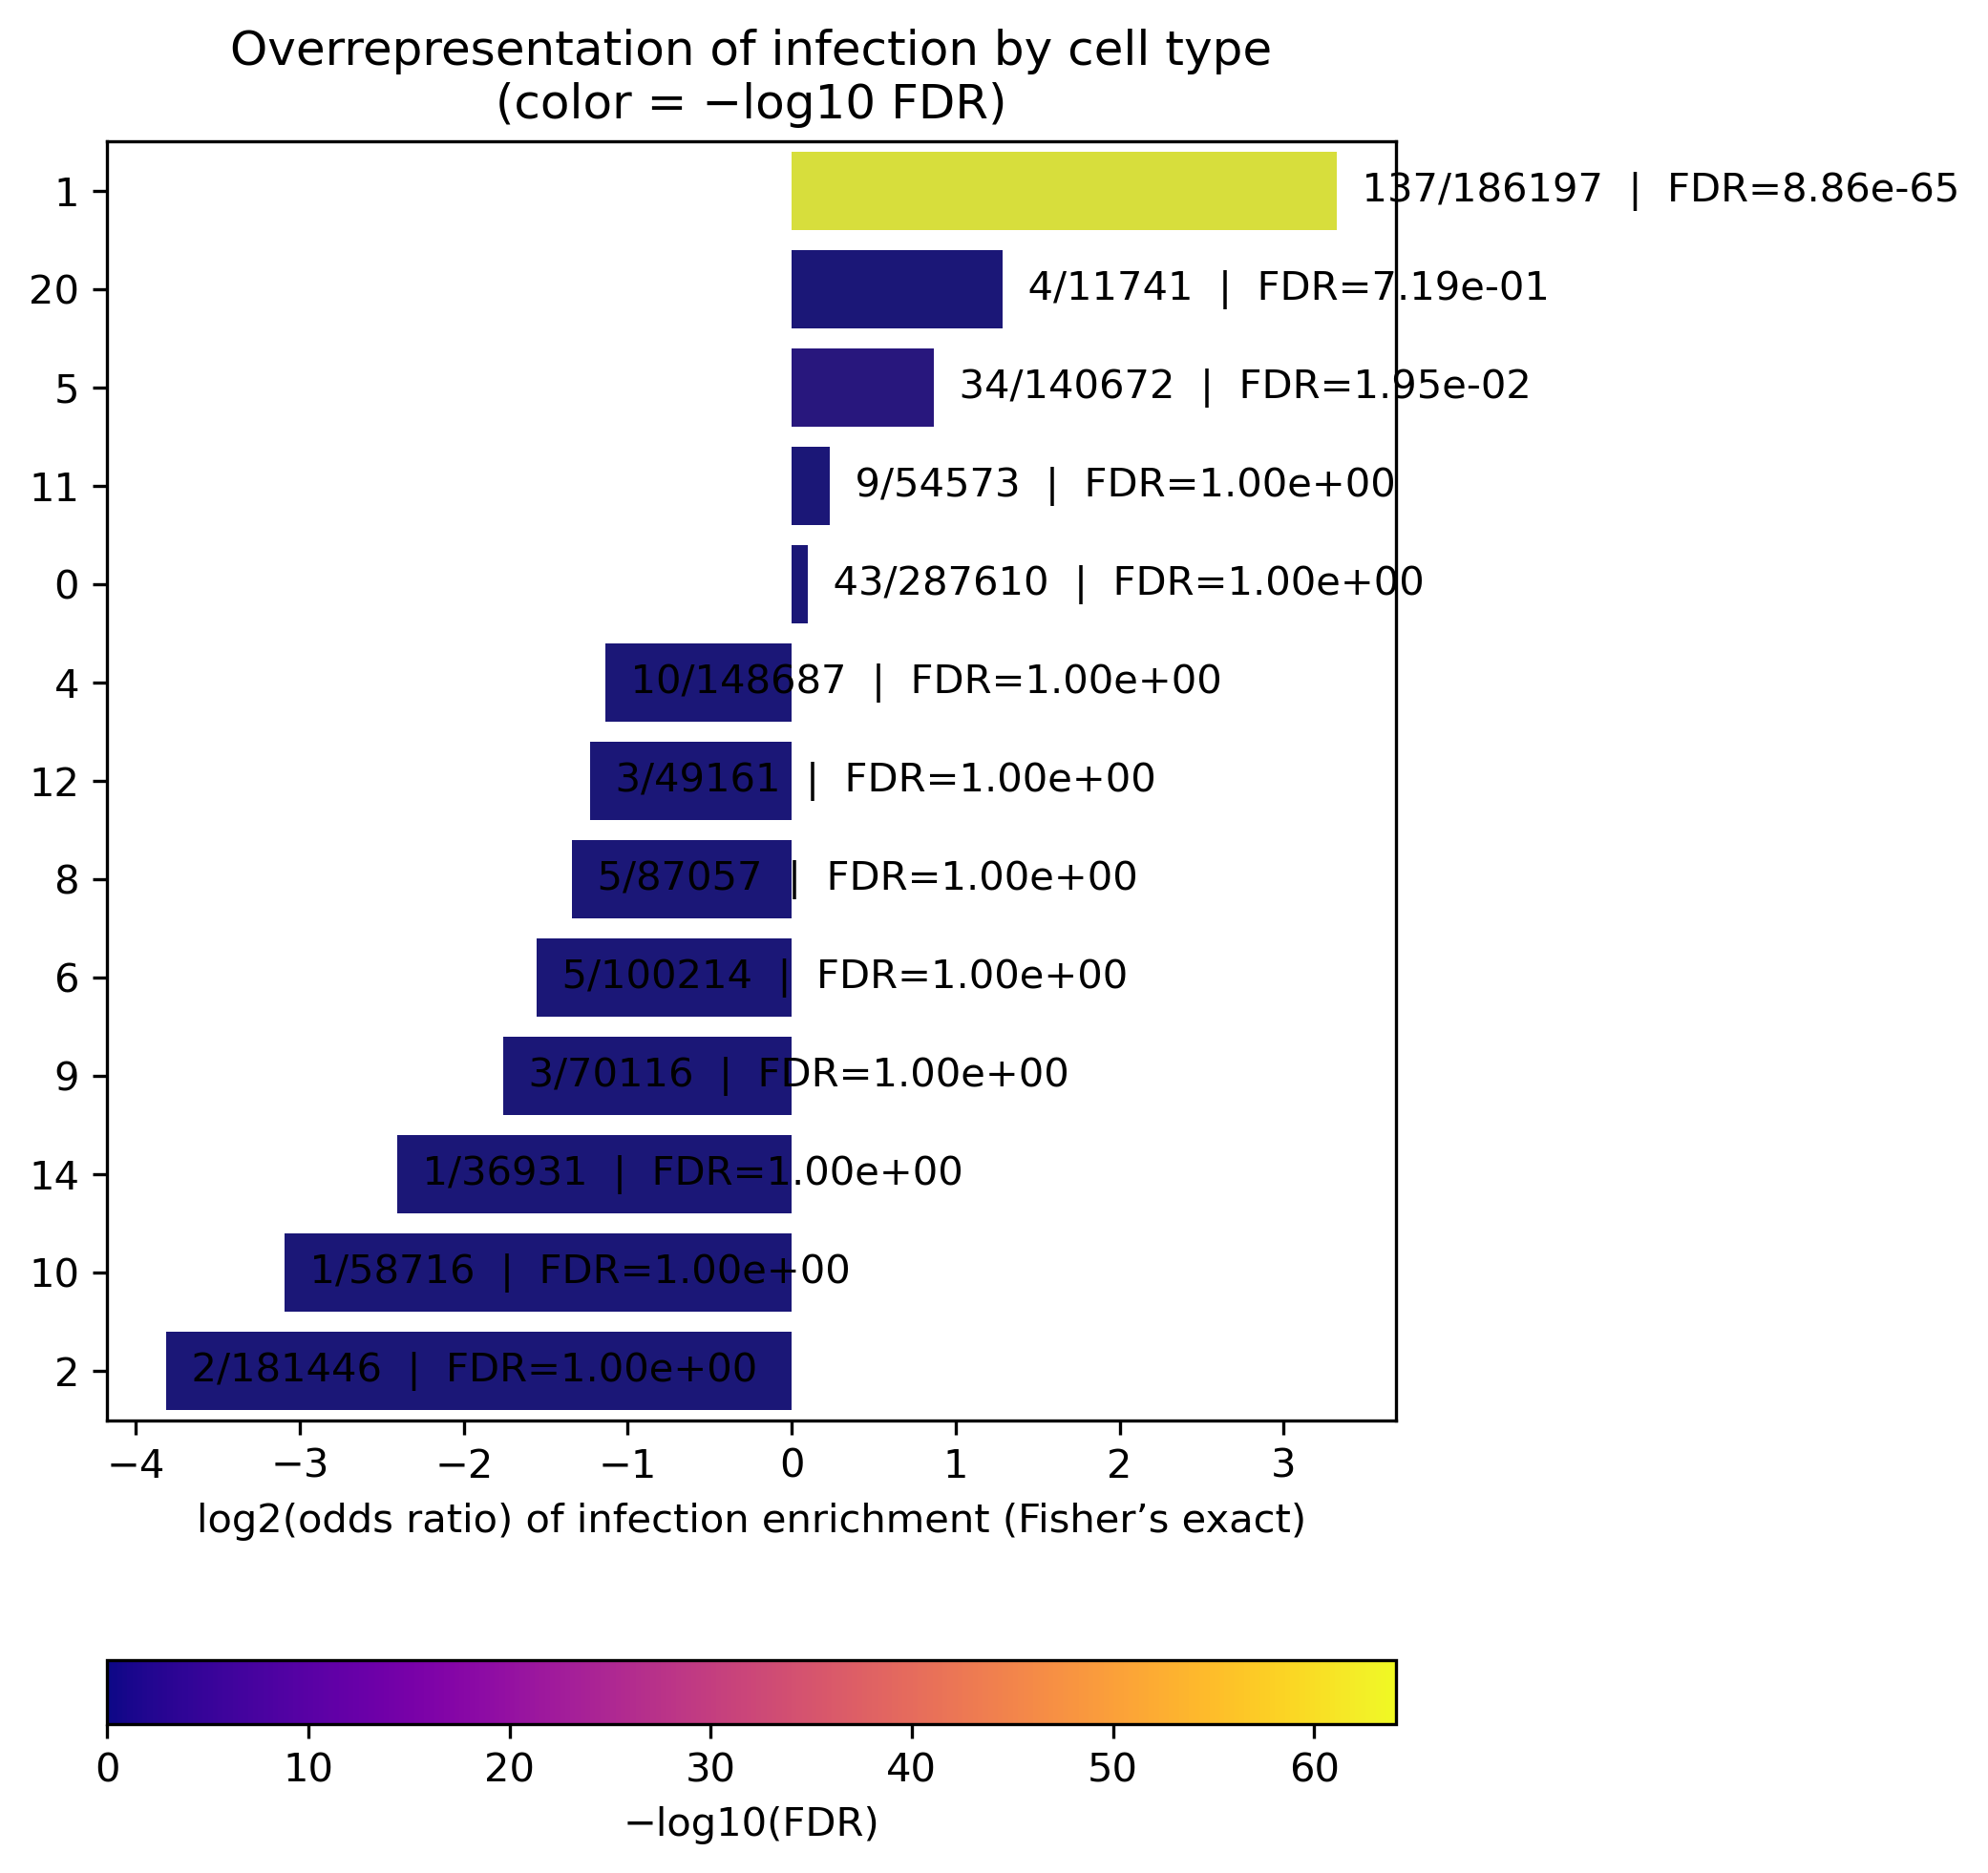

In [25]:
# --- Overrepresentation plot: clean version ---

# Filter out cell types with zero infected (OR undefined)
plot_df = enrichment[enrichment["infected"] > 0].copy()

# Compute log2 odds ratios safely
plot_df["odds_ratio"] = plot_df["odds_ratio"].replace([np.inf, -np.inf], np.nan)
plot_df["log2_or"] = np.log2(plot_df["odds_ratio"])
plot_df["log2_or"] = plot_df["log2_or"].clip(upper=5)   # cap for display

# Significance scale
plot_df["neglog10_fdr"] = -np.log10(plot_df["pval_adj"].clip(lower=1e-300))

# Sort by enrichment
plot_df = plot_df.sort_values("log2_or", ascending=False).reset_index(drop=True)

# Figure size consistent with others
n_ct = max(len(scores_viz), len(merged), len(plot_df))
plt.figure(figsize=(7, 0.35*n_ct))

# Continuous color mapping for significance
norm = mpl.colors.Normalize(vmin=0, vmax=plot_df["neglog10_fdr"].max())
cmap = plt.cm.plasma
colors = [cmap(norm(v)) for v in plot_df["neglog10_fdr"]]

# Barplot
ax = sns.barplot(
    data=plot_df,
    x="log2_or",
    y="cell_type",
    palette=colors,
    dodge=False
)
ax.set_xlabel("log2(odds ratio) of infection enrichment (Fisher’s exact)")
ax.set_ylabel("")
ax.set_title("Overrepresentation of infection by cell type\n(color = −log10 FDR)")

# Annotate infected/total and FDR
for i, row in plot_df.iterrows():
    es = row["log2_or"]
    a = int(row["infected"]); nt = int(row["n_total"])
    fdr = row["pval_adj"]
    plt.text(es, i, f"  {a}/{nt}  |  FDR={fdr:.2e}", va="center")

# Colorbar
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, orientation="horizontal", pad=0.15, fraction=0.05)
cbar.set_label("−log10(FDR)")

plt.tight_layout()
plt.subplots_adjust(bottom=0.3)
plt.show()

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


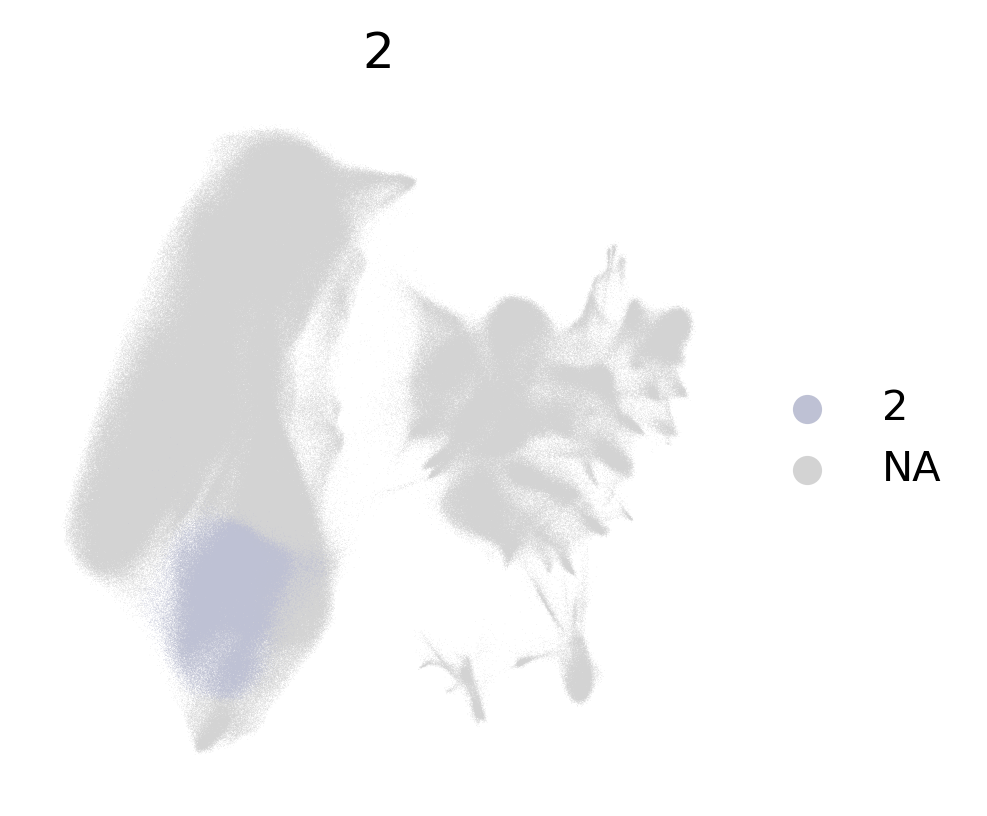

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


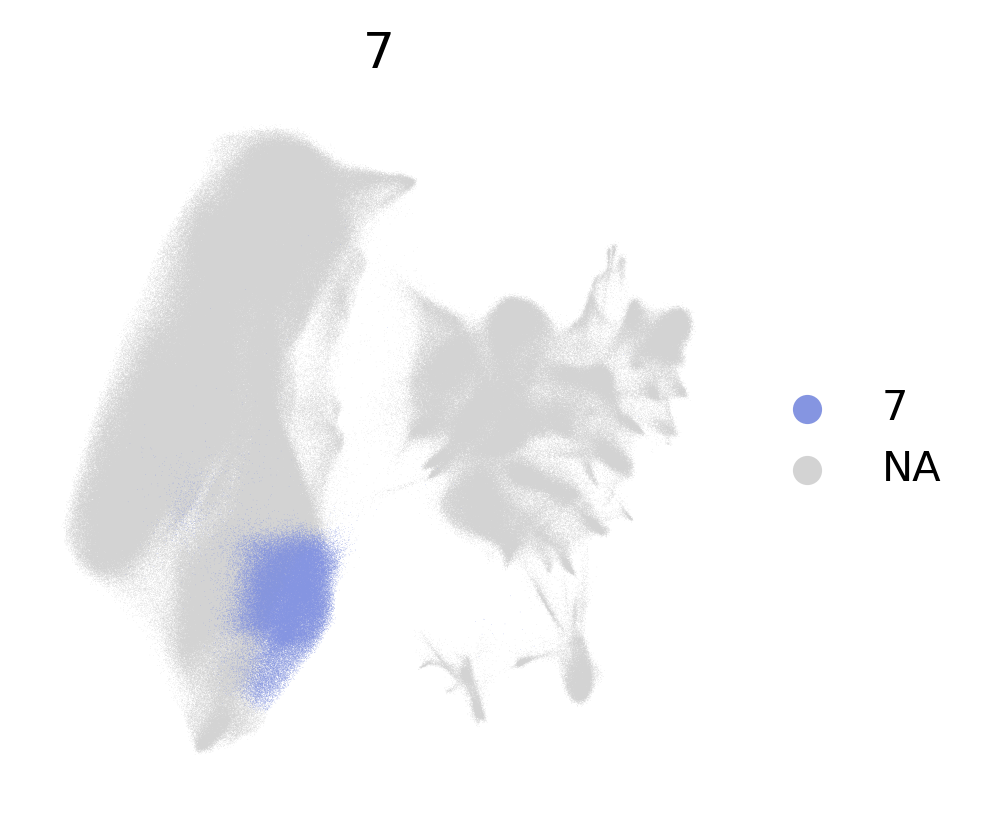

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


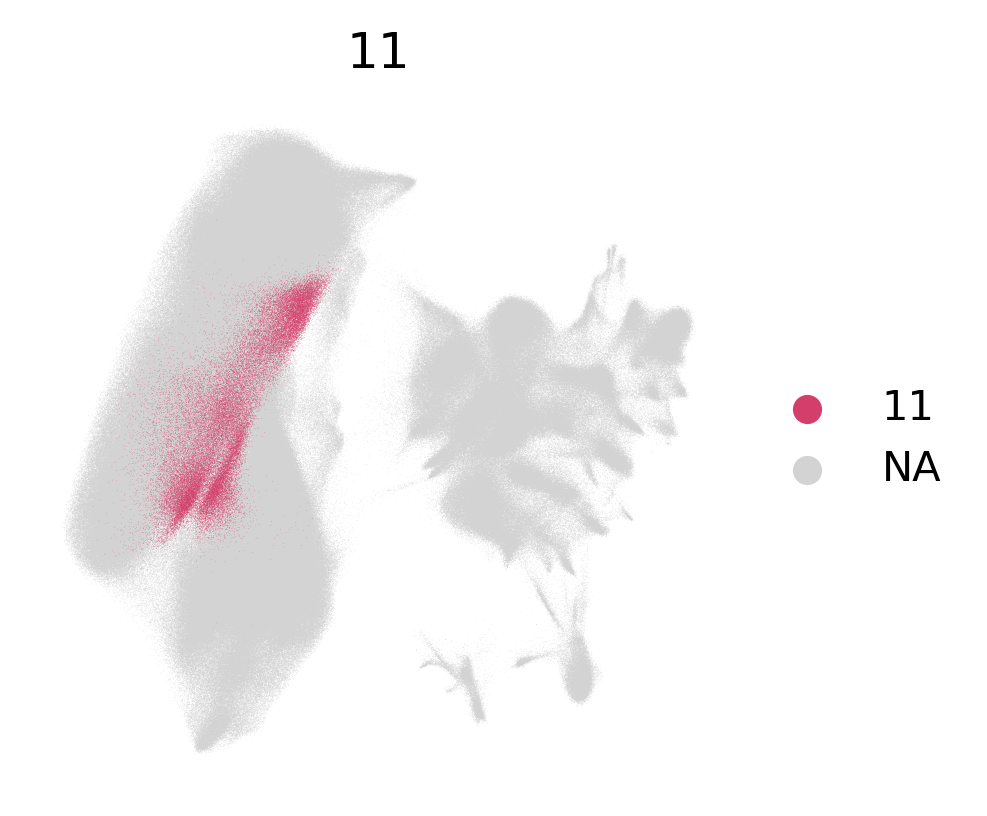

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


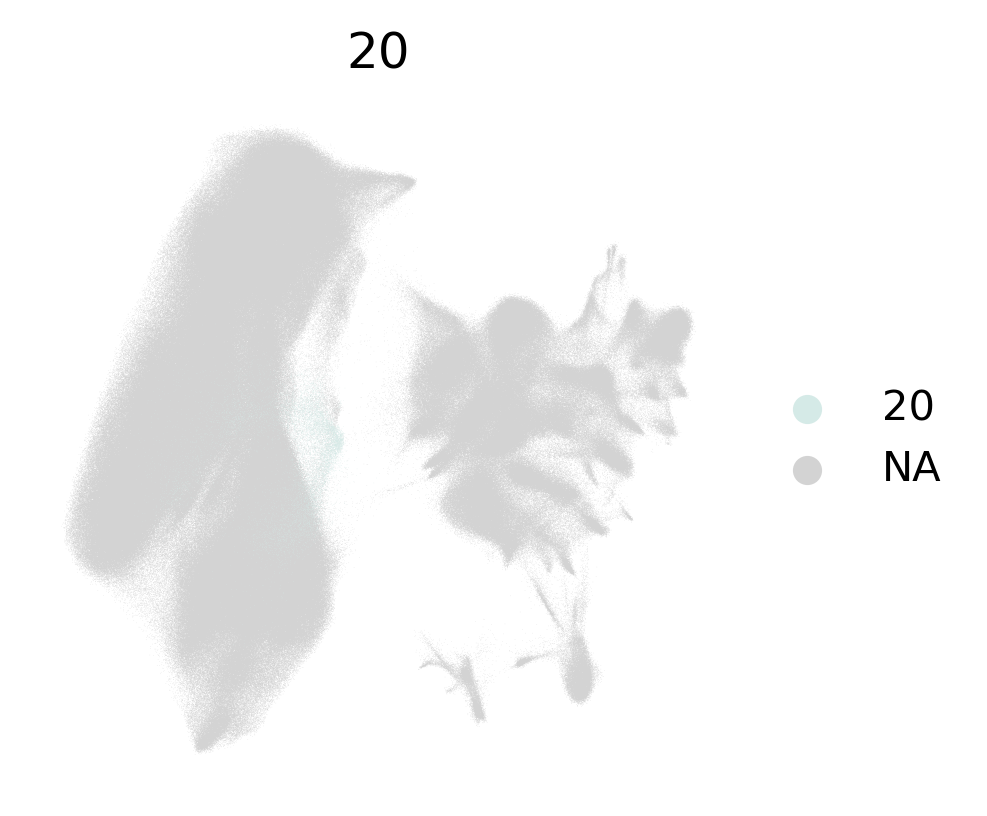

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


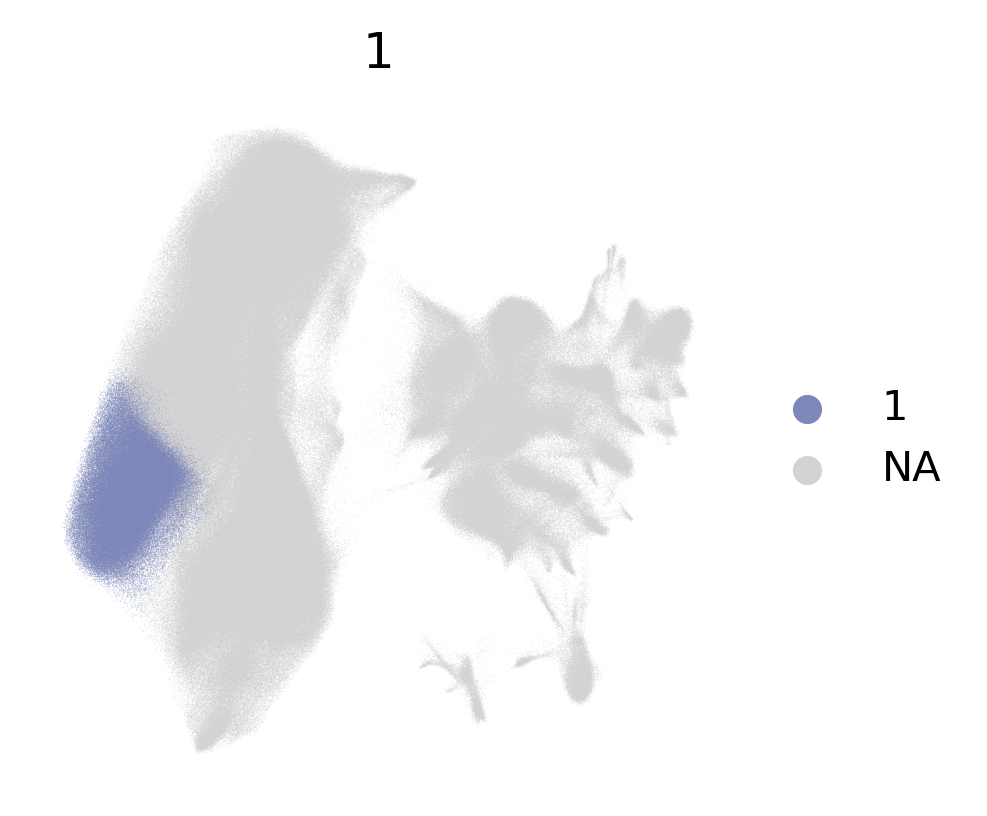

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


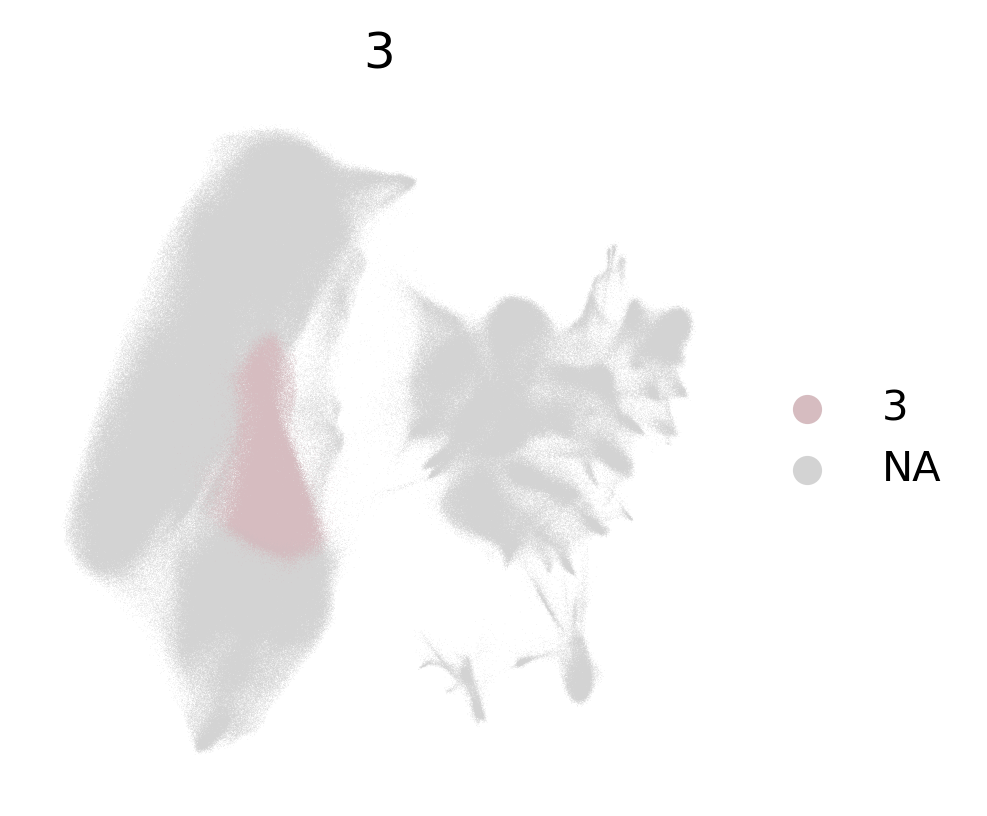

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


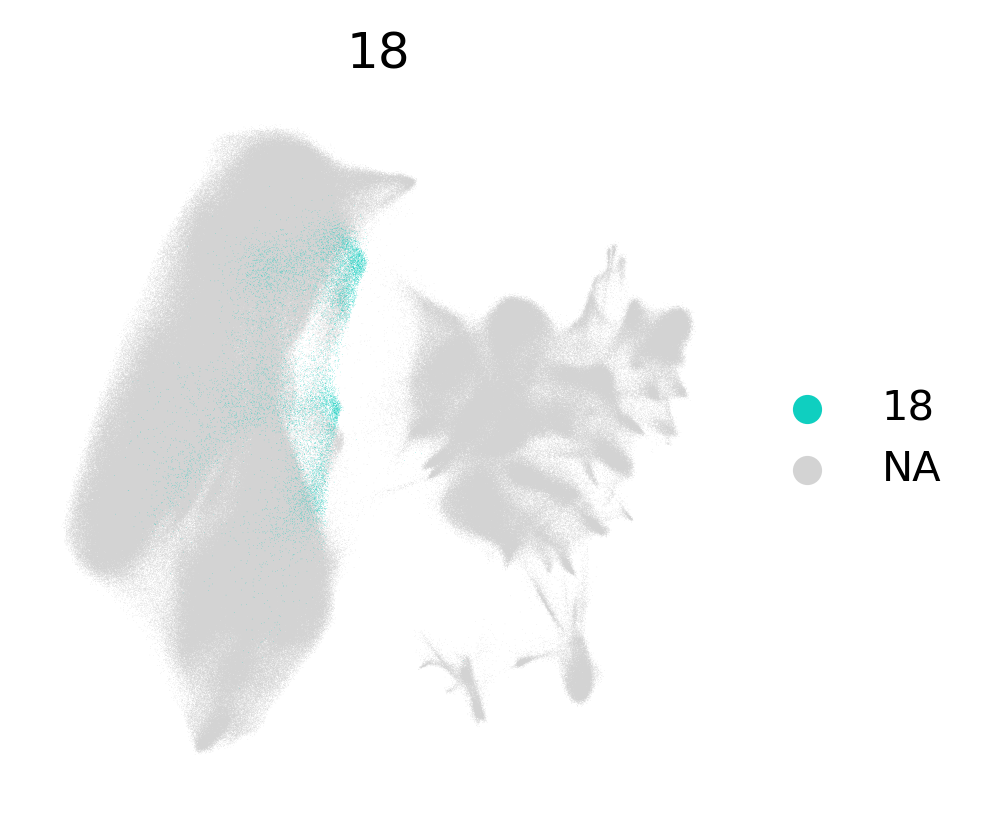

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


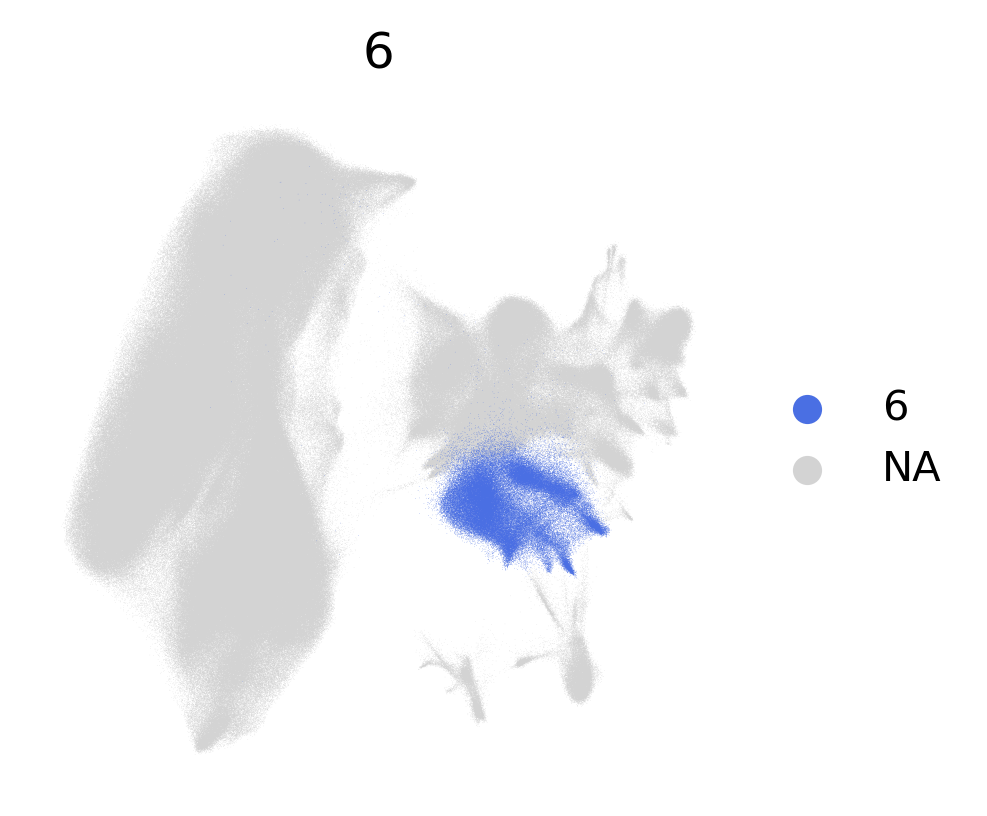

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


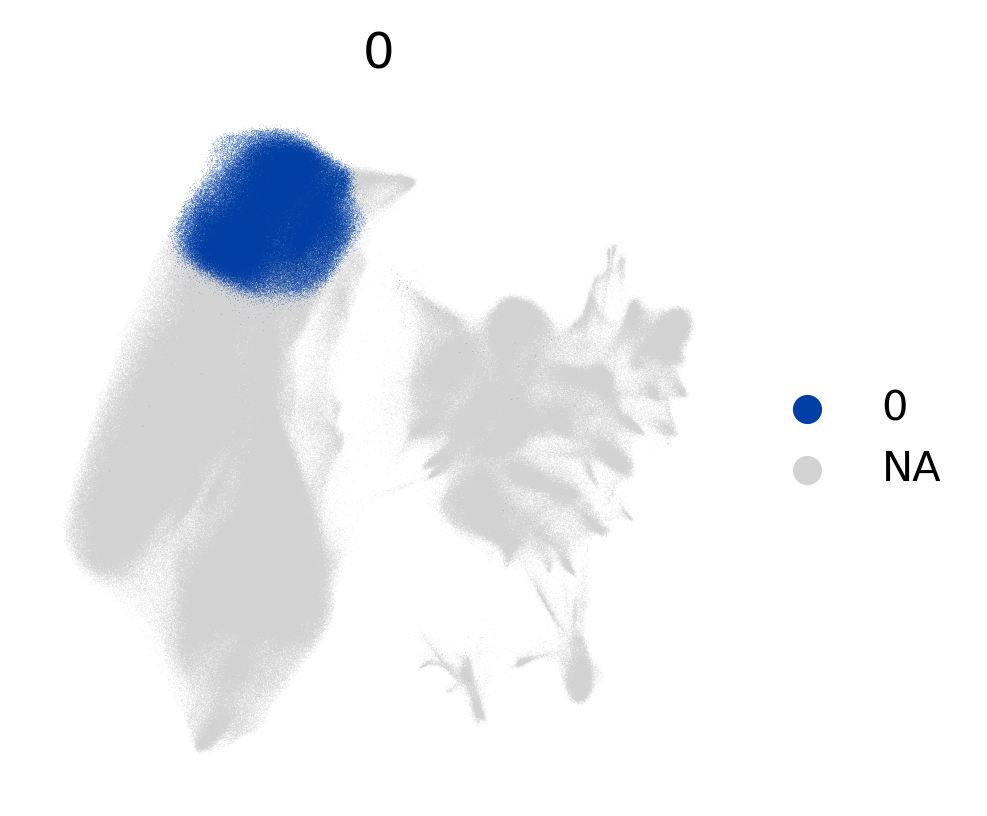

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


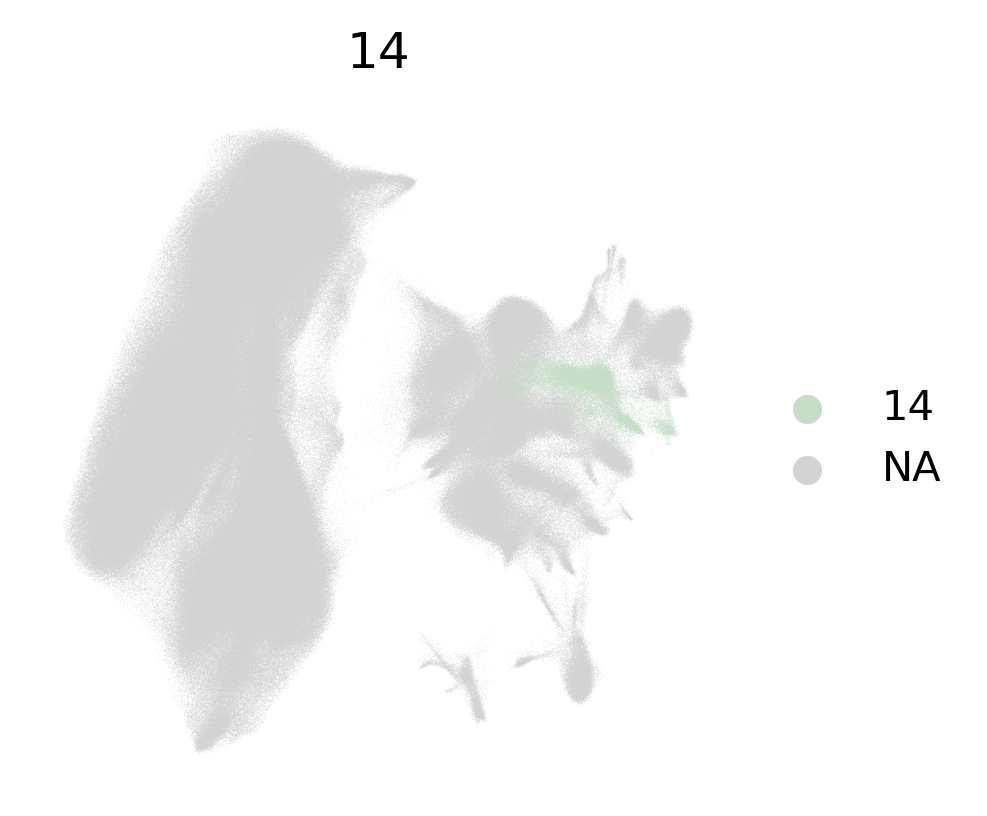

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


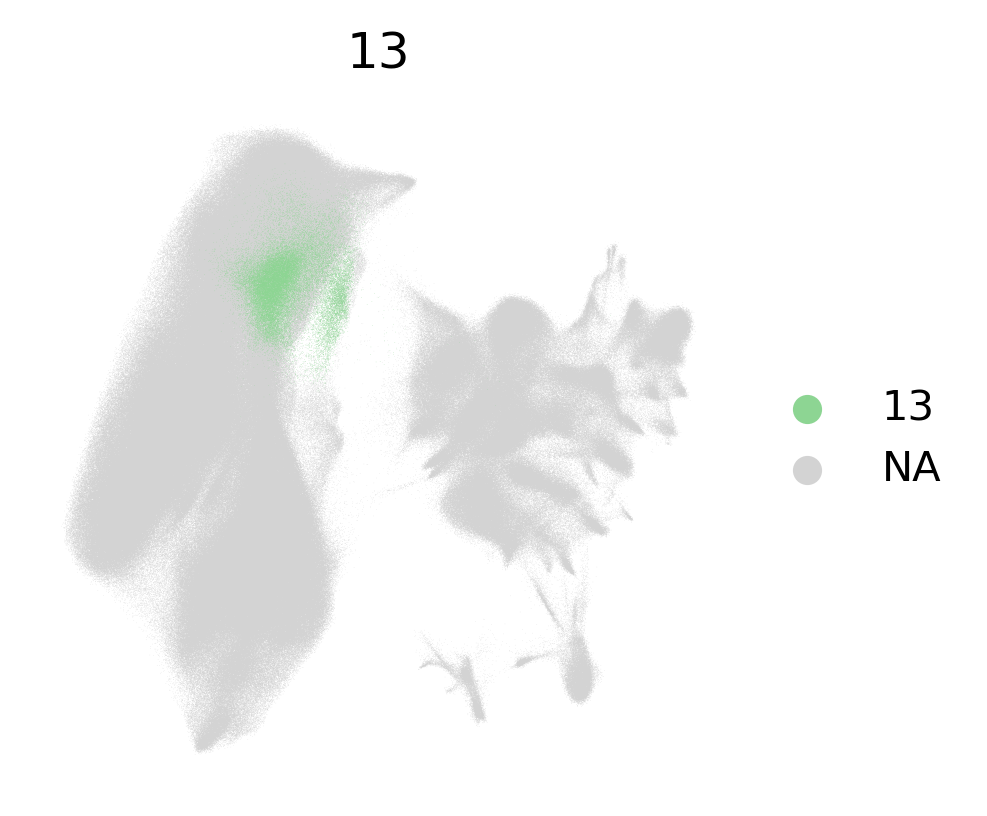

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


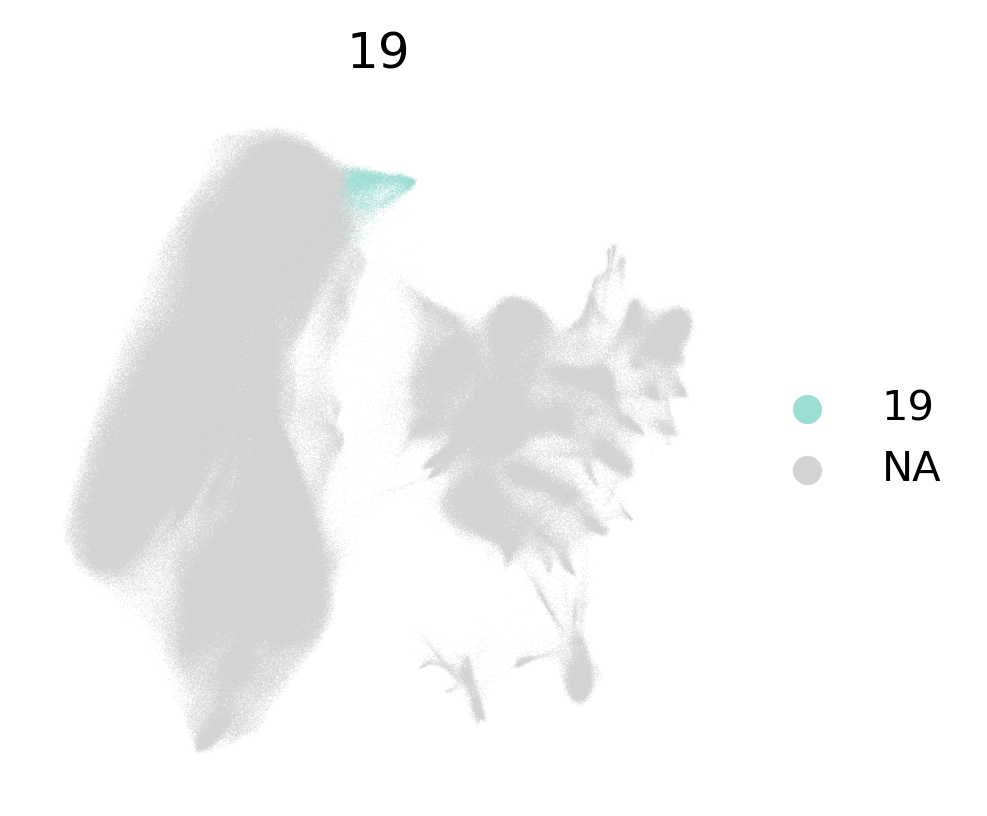

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


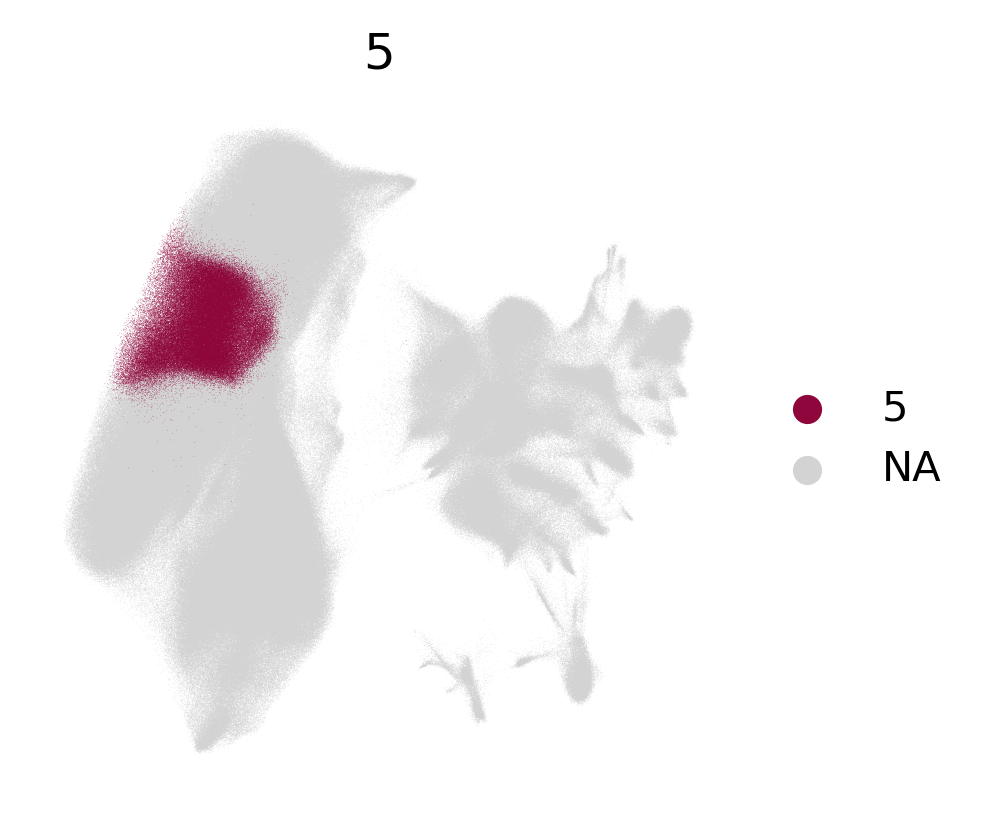

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


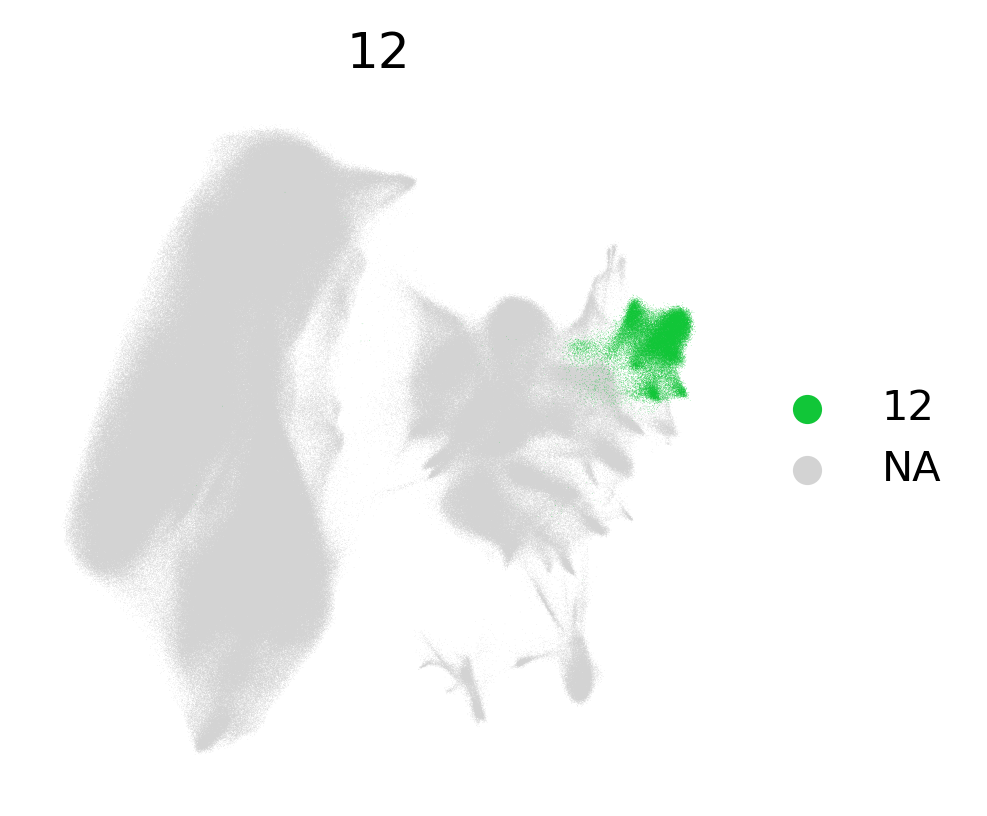

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


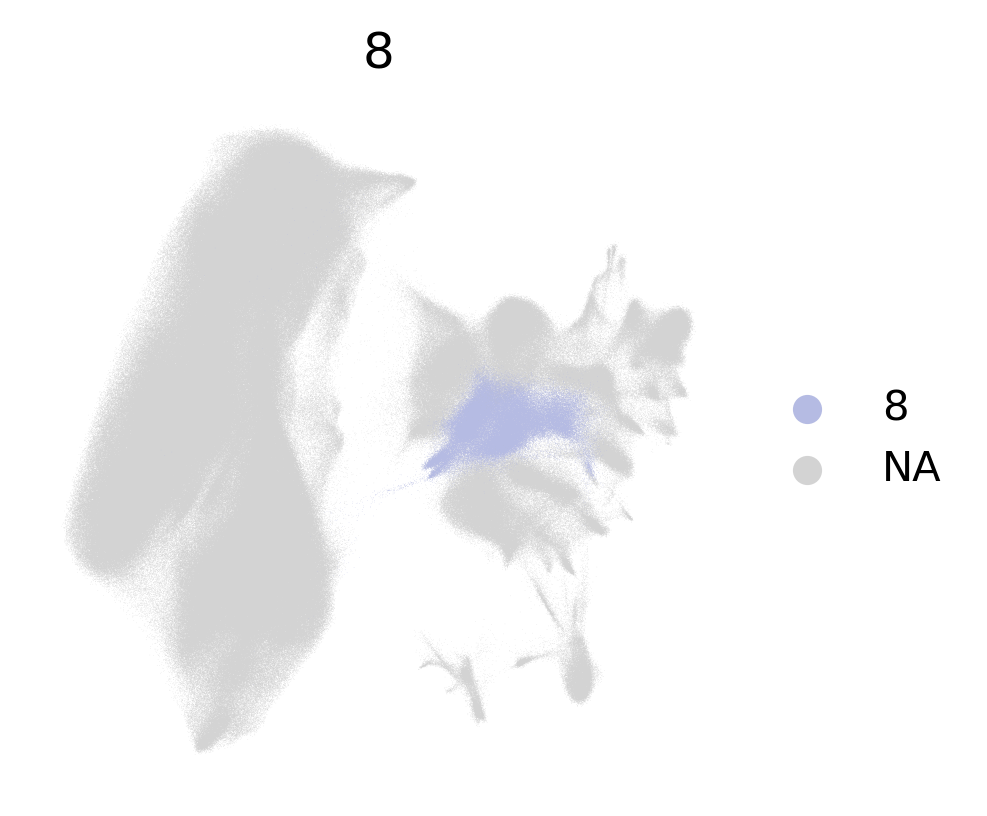

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


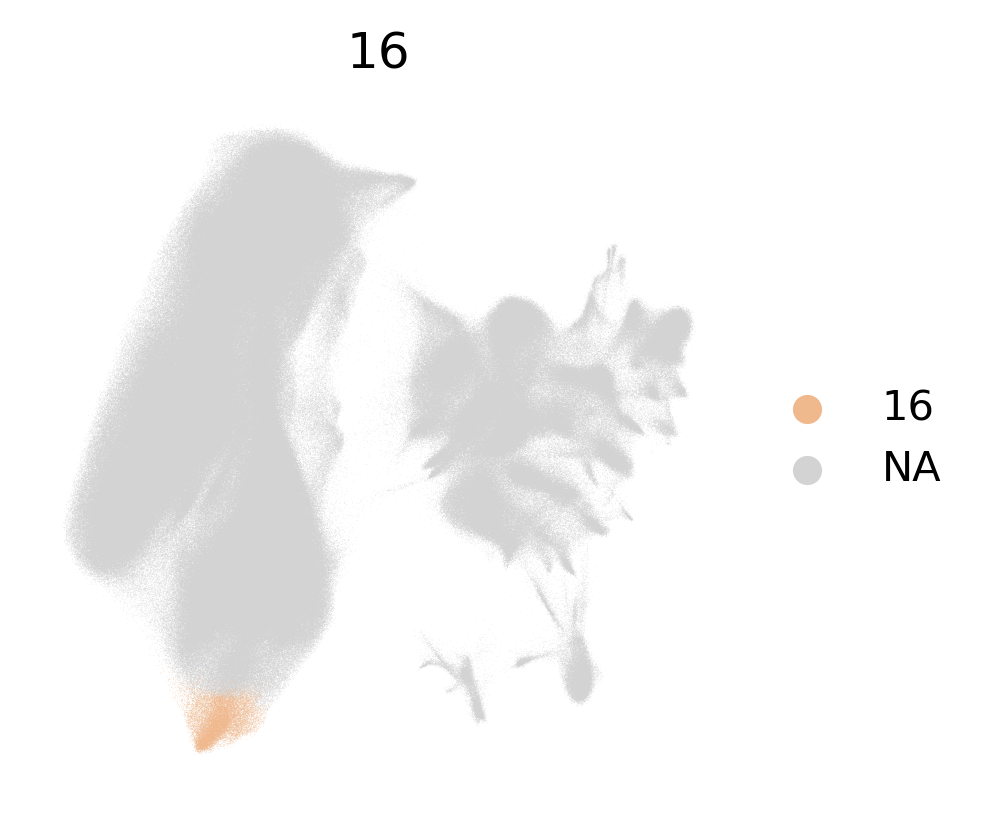

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


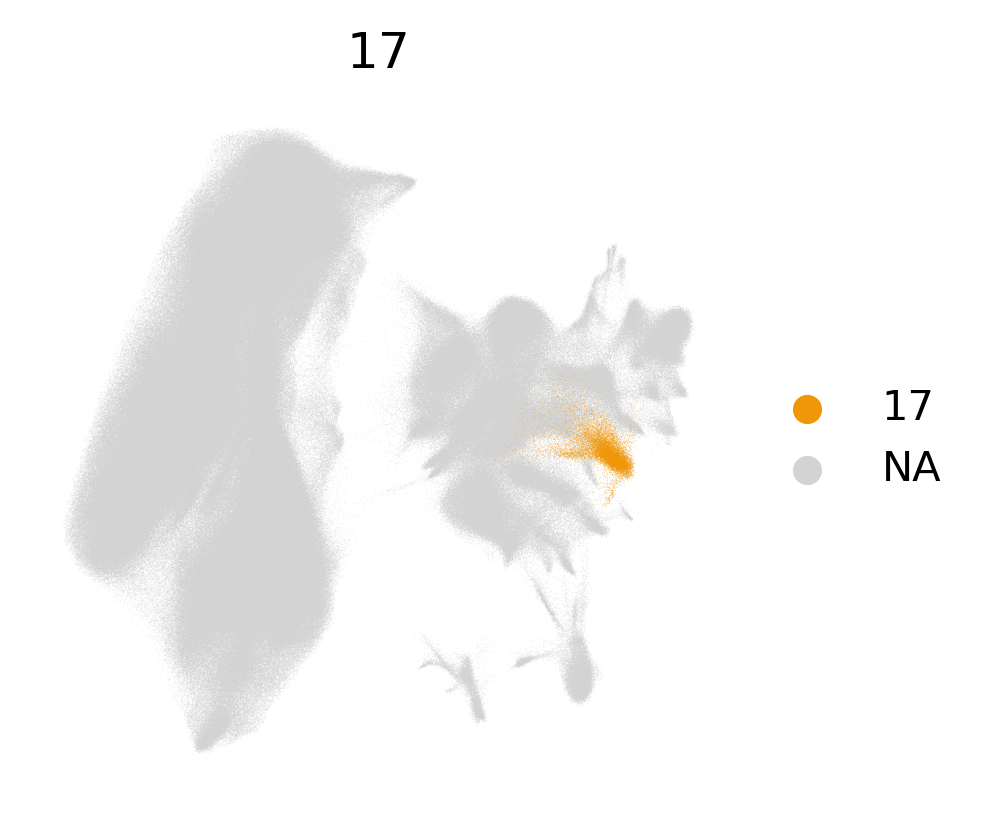

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


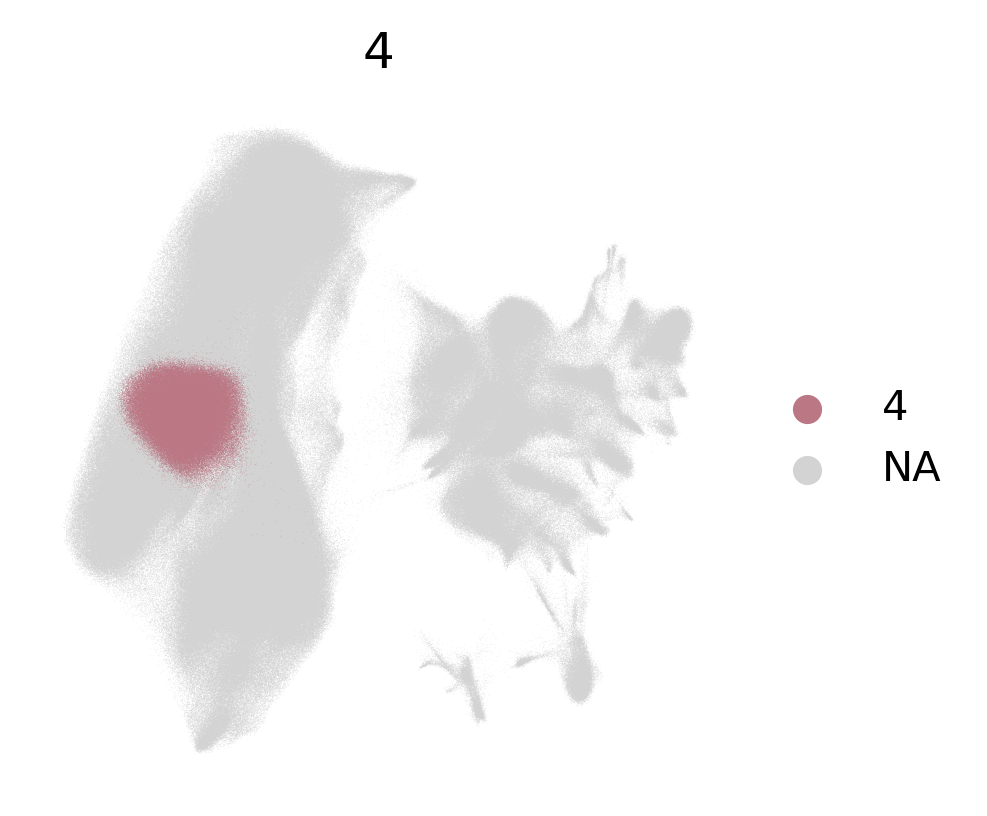

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


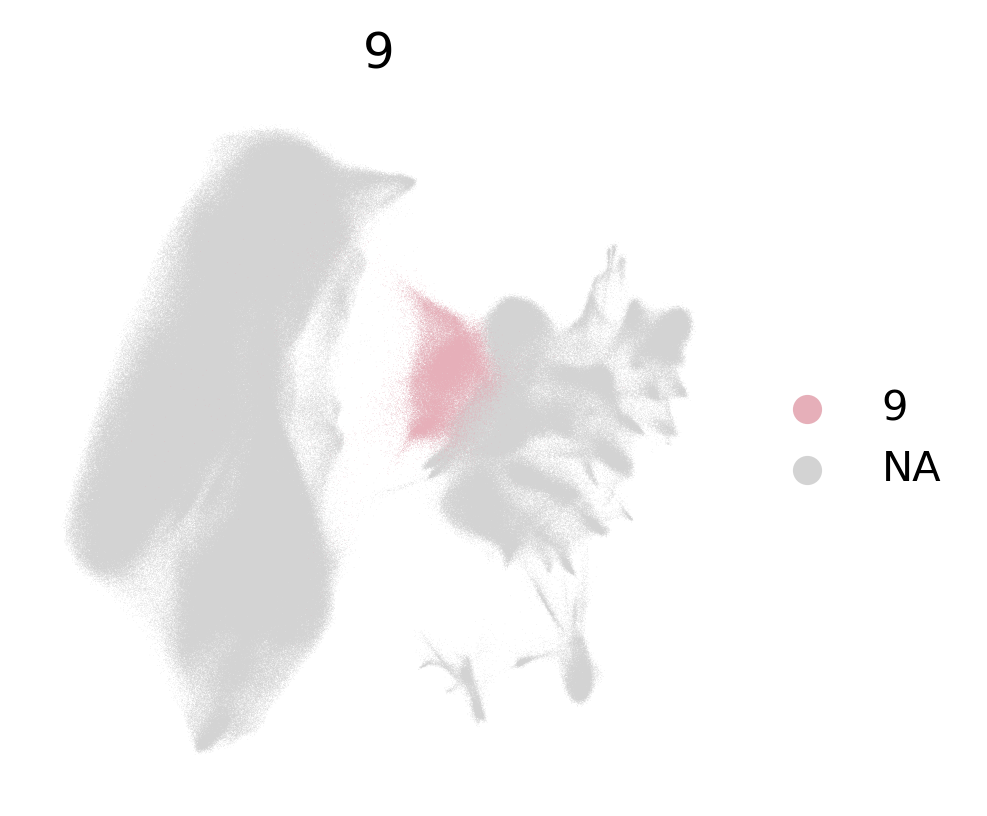

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


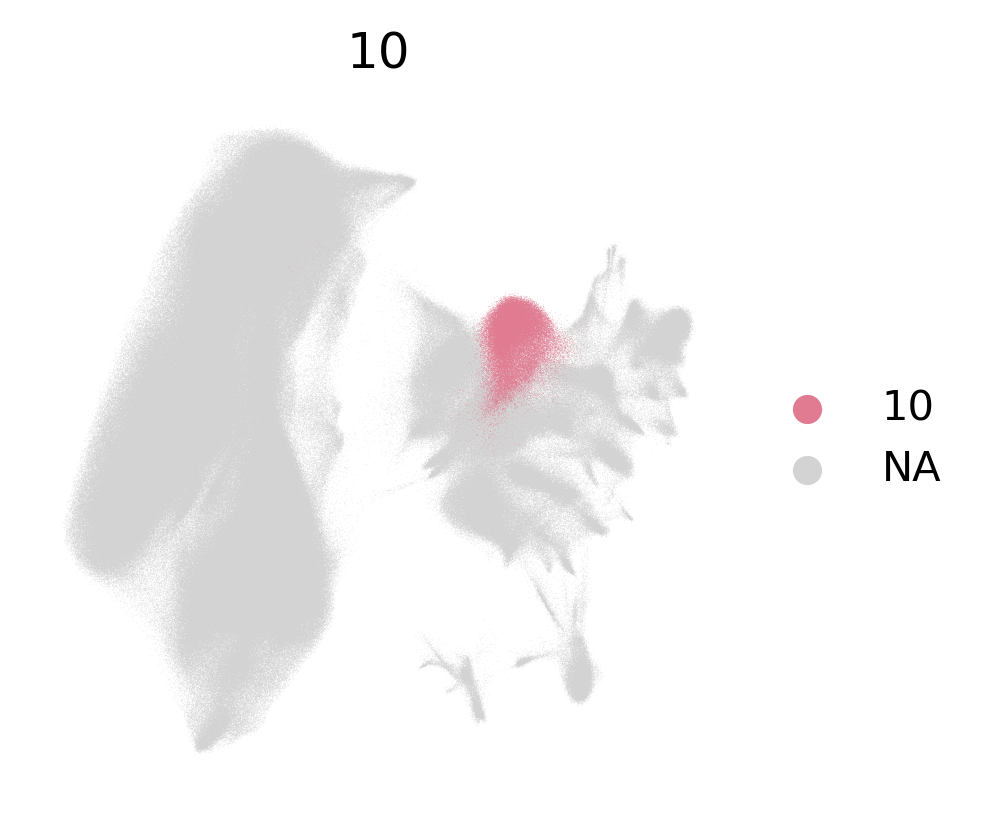

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


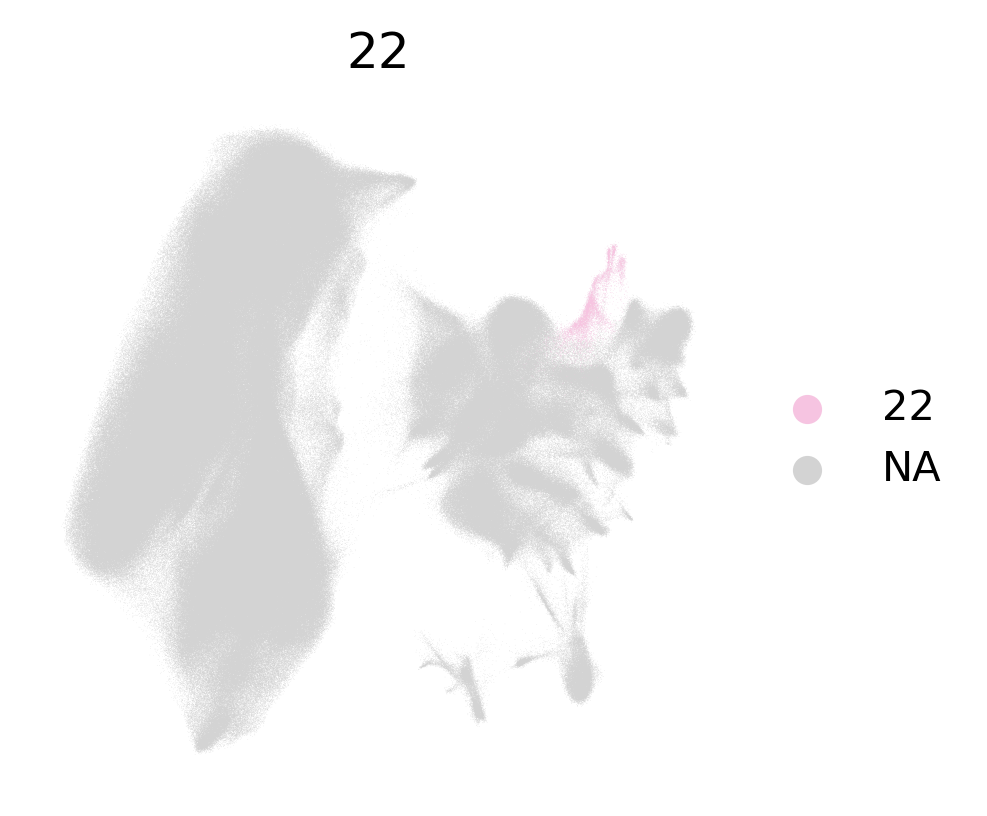

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


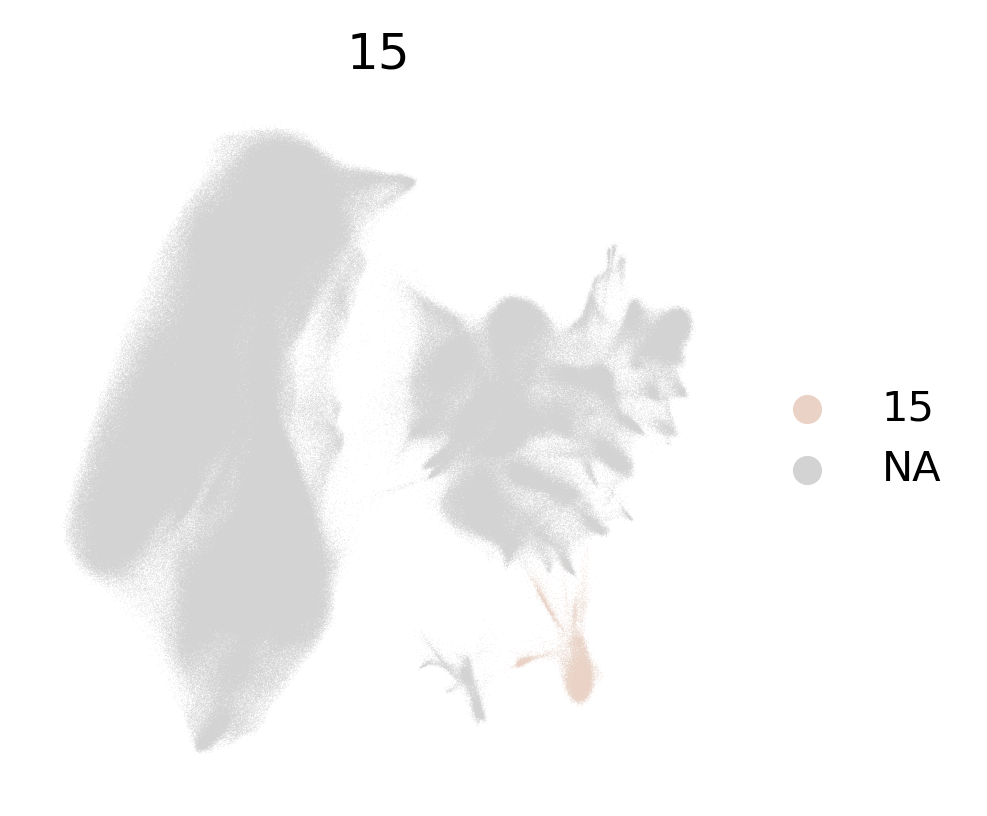

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


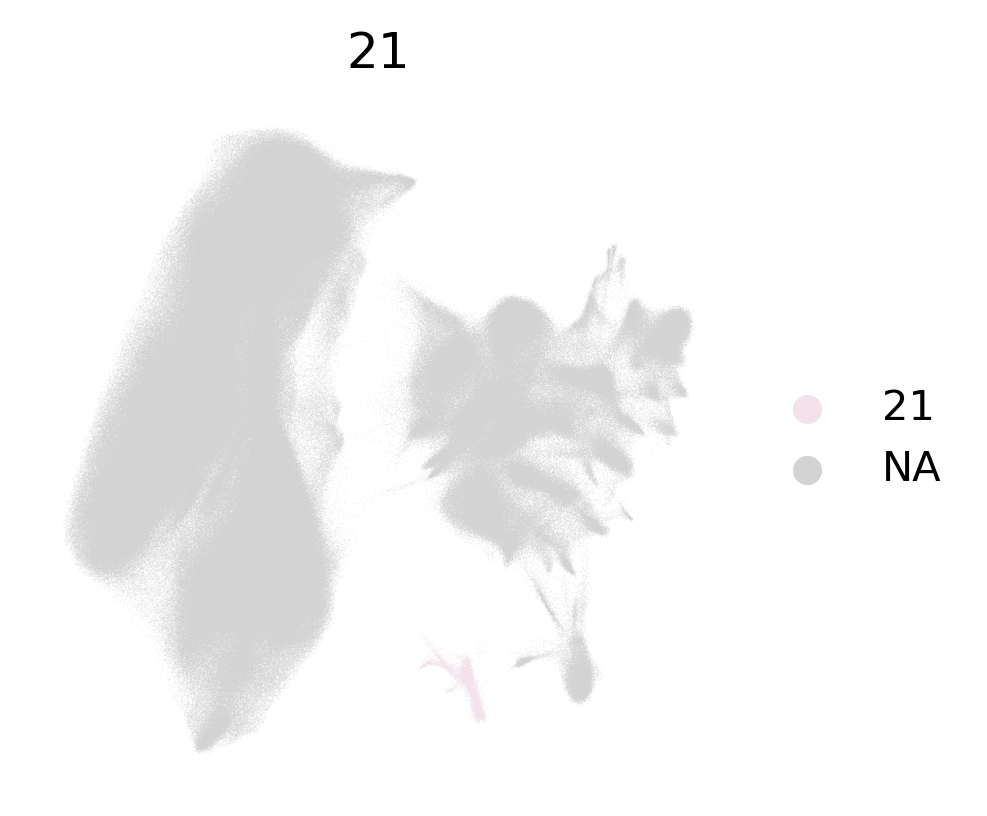

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


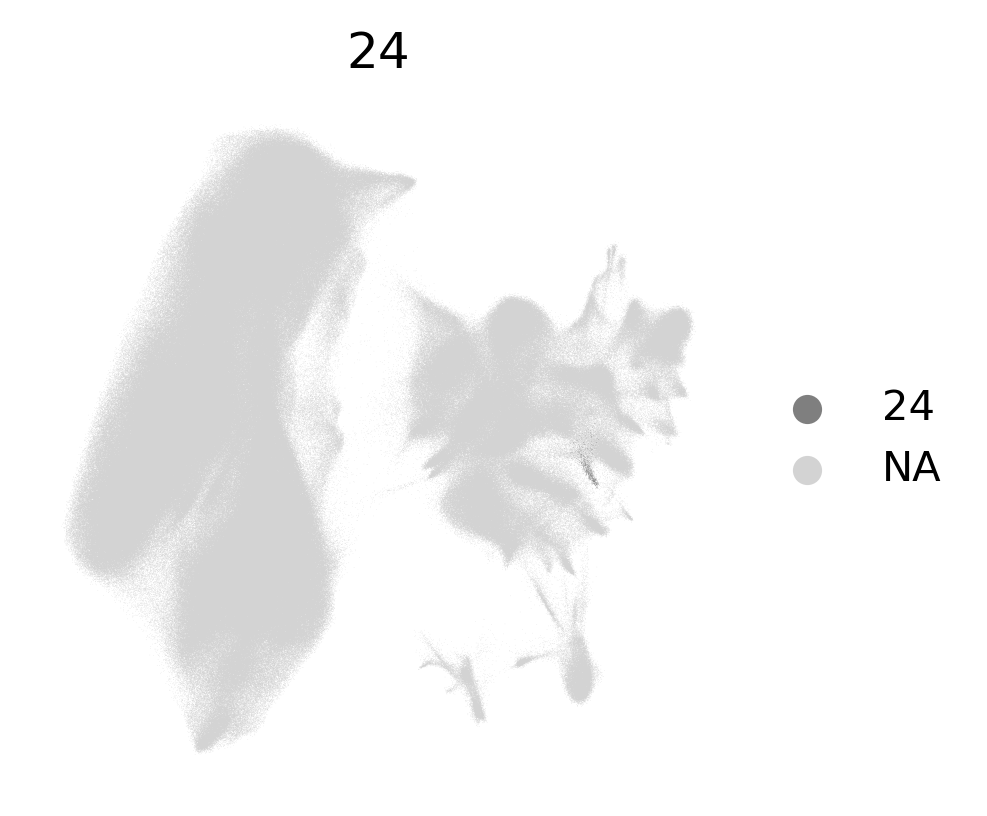

/home/workspace/environment/sc-spatial/lib/python3.12/site-packages/scanpy/plotting/_tools/scatterplots.py:394: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap' will be ignored
  cax = scatter(


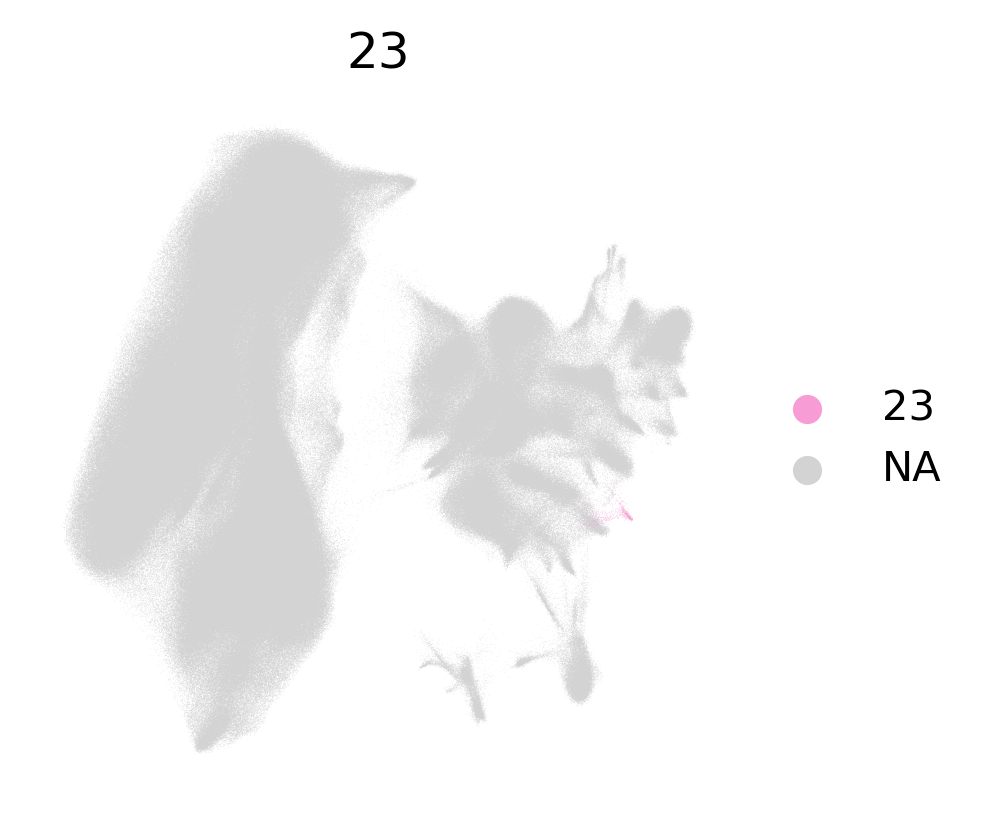

In [18]:
for celltype in adata.obs['leiden_scVI_1'].unique():
    sc.pl.umap(
        adata,
        color='cell_type',
        groups=[celltype],
        frameon=False,
        title=celltype,
        show=True
    )

Greedy best match per Leiden cluster:


,cluster_size,best_label,best_fraction,n_in_best
leiden_scVI_1,,,,
0,287610,Transit_Amplifying,0.944348,271604
1,186197,Enterocyte_1,0.624419,116265
10,58716,Myofibroblast,0.743153,43635
11,54573,Goblet,0.563612,30758
12,49161,Myofibroblast,0.827302,40671
13,40398,Transit_Amplifying,0.836403,33789
14,36931,Fibroblast,0.607268,22427
15,20634,Paneth,0.809198,16697
16,18316,Enterocyte_1,0.996287,18248


Global one-to-one Leiden ↔ scANVI mapping (Hungarian):


,leiden,label,fraction,count
0,0,Transit_Amplifying,0.944348,271604
1,1,Monocyte,0.002433,453
2,10,Myofibroblast,0.743153,43635
3,11,Goblet,0.563612,30758
4,12,Fibroblast_Pdgfra+,0.093692,4606
5,13,B-Cell,0.000099,4
6,14,Resting Fibroblast,0.297582,10990
7,15,Paneth,0.809198,16697
8,16,Enterocyte_1,0.996287,18248
9,17,Lymphatic,0.871268,14416


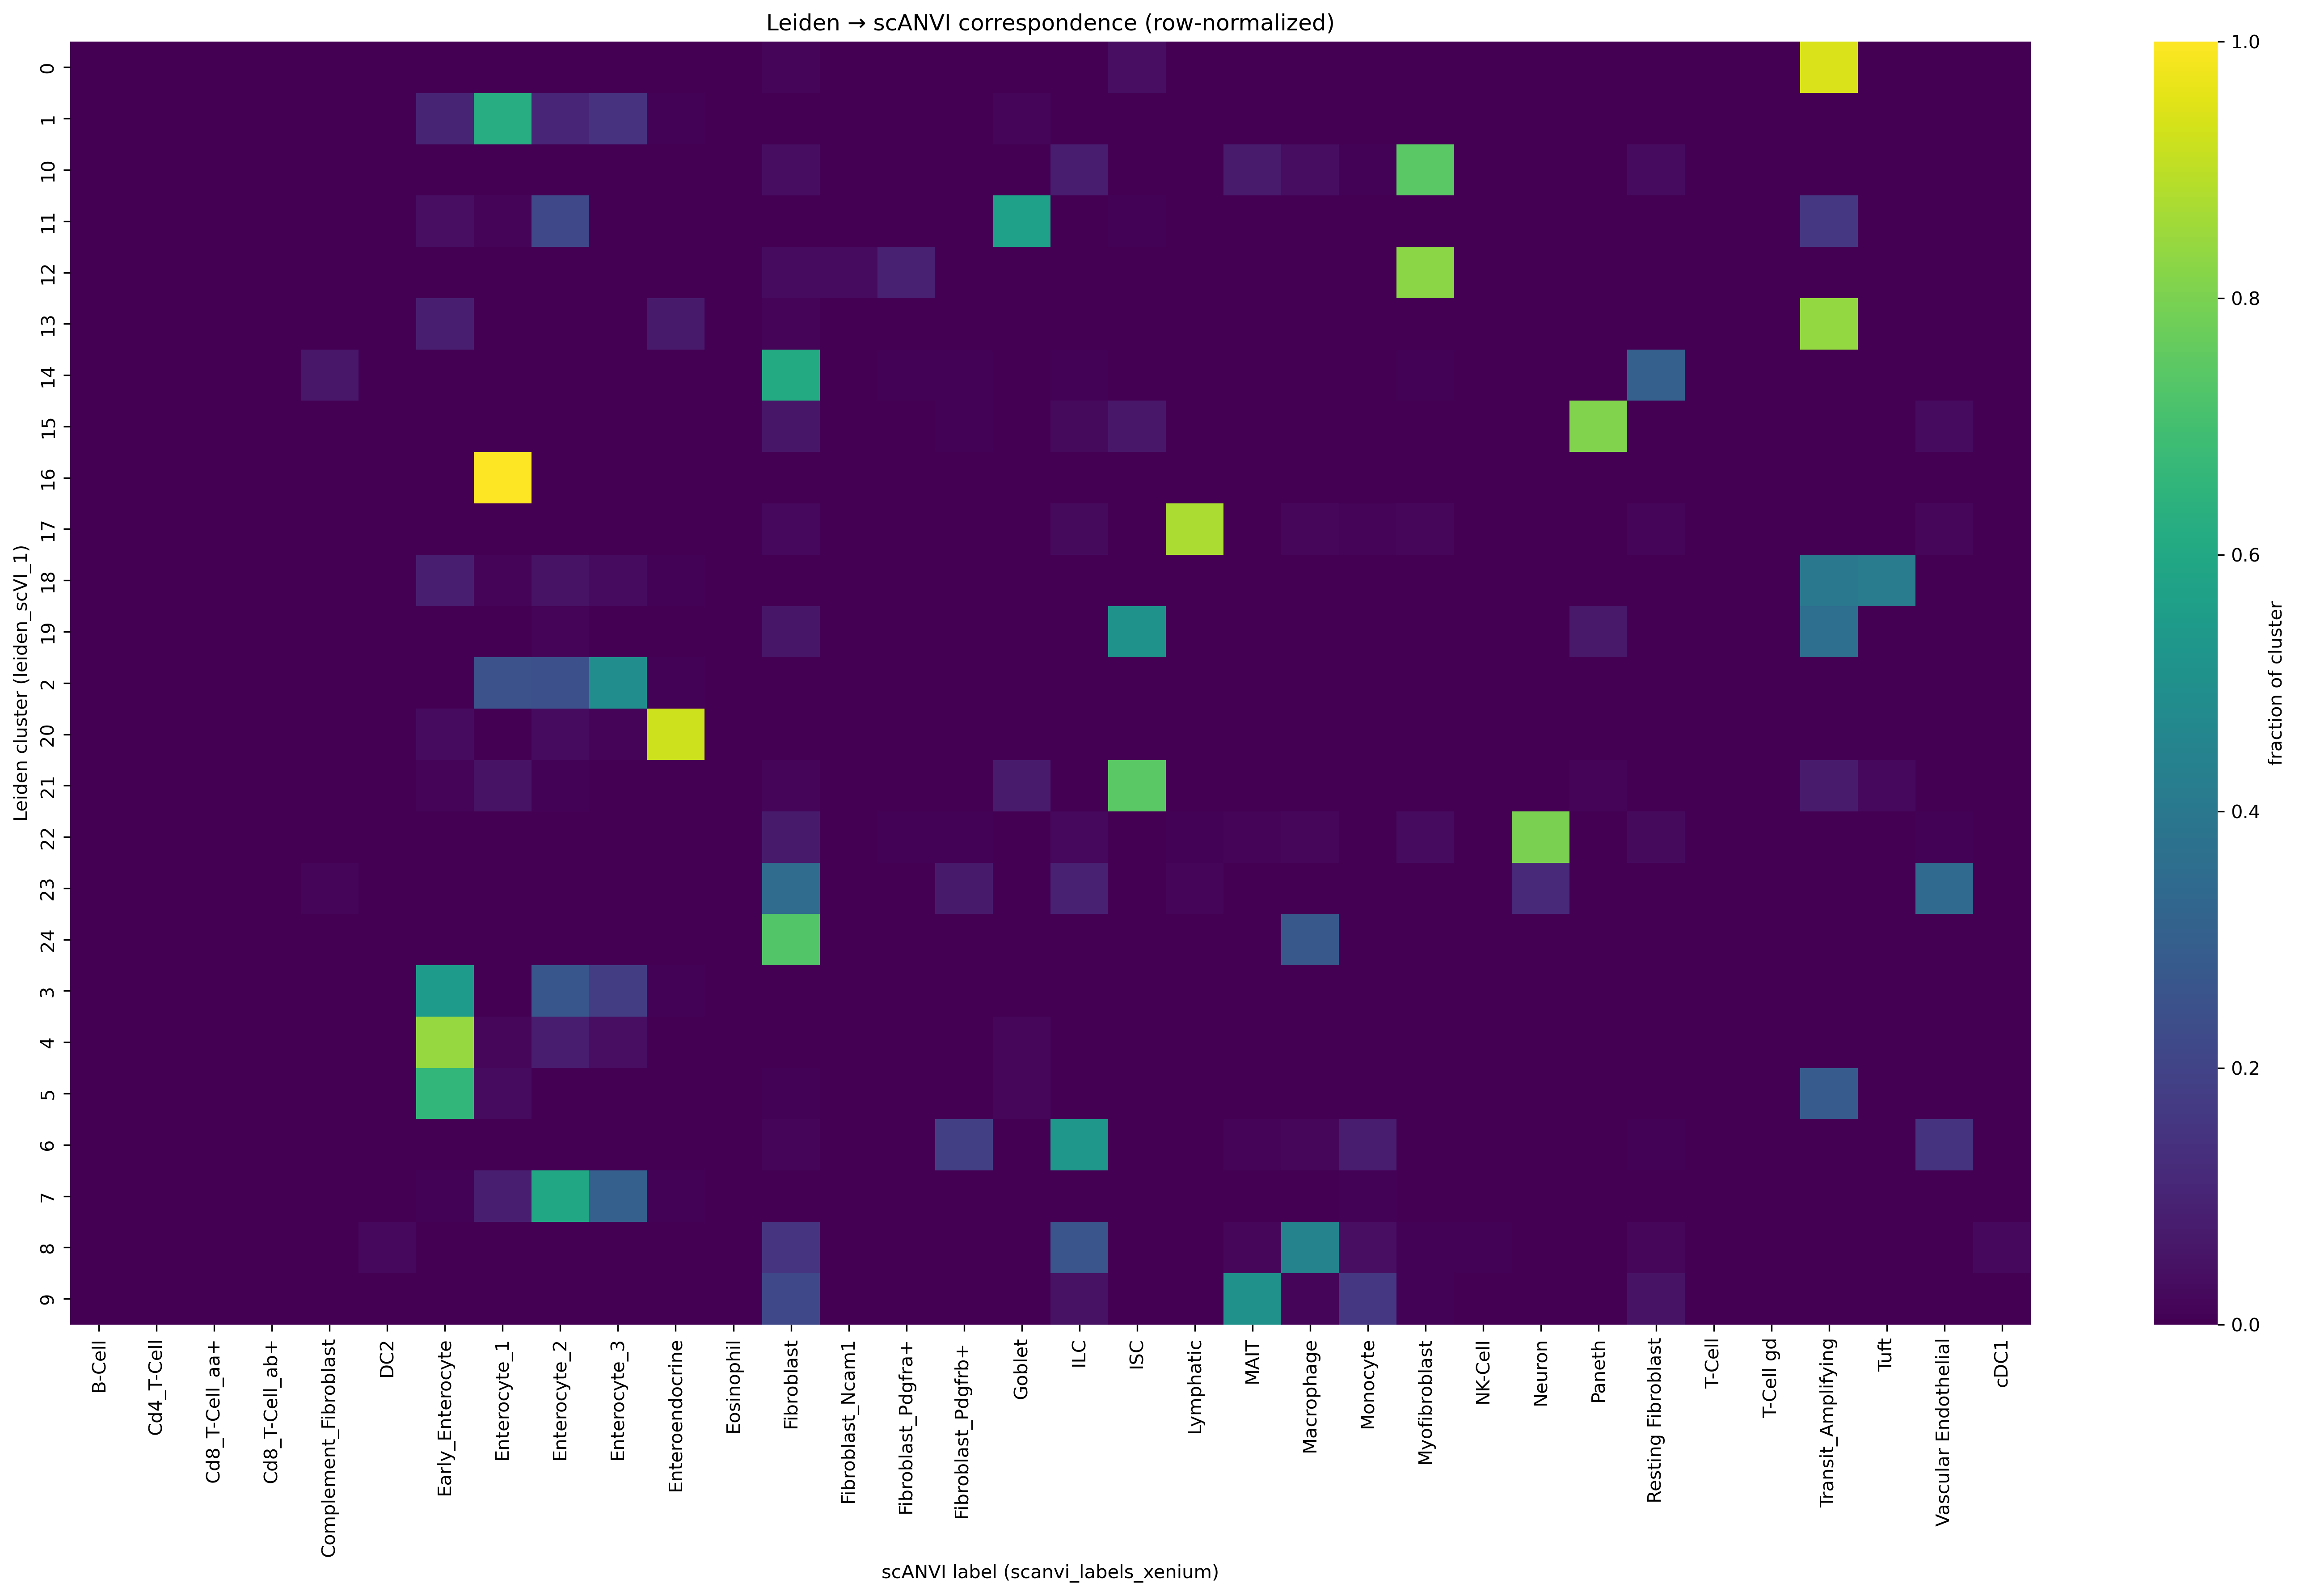

Ambiguous/mixed clusters (best_fraction < 0.6):


,cluster_size,best_label,best_fraction,n_in_best
leiden_scVI_1,,,,
11,54573,Goblet,0.563612,30758
18,13072,Tuft,0.412714,5395
19,12938,ISC,0.508270,6576
2,181446,Enterocyte_3,0.492135,89296
23,789,Fibroblast,0.349810,276
3,168088,Early_Enterocyte,0.545732,91731
6,100214,ILC,0.531533,53267
7,99794,Enterocyte_2,0.596218,59499
8,87057,Macrophage,0.446684,38887


In [32]:
import pandas as pd
import numpy as np
from scipy.optimize import linear_sum_assignment
import matplotlib.pyplot as plt
import seaborn as sns

# ---- keys ----
leiden_key = "leiden_scVI_1"
label_key  = "scanvi_labels_xenium"

# Drop missing to avoid spurious categories
obs = adata.obs[[leiden_key, label_key]].dropna().copy()

# Ensure strings (optional, but avoids category surprises)
obs[leiden_key] = obs[leiden_key].astype(str)
obs[label_key]  = obs[label_key].astype(str)

# ---- contingency & fractions ----
ct = pd.crosstab(obs[leiden_key], obs[label_key])              # counts: clusters × labels
frac = ct.div(ct.sum(axis=1).replace(0, np.nan), axis=0)       # row-normalized fractions

# ---- greedy "best label per cluster" ----
best_label = frac.idxmax(axis=1).rename("best_label")
best_frac  = frac.max(axis=1).rename("best_fraction")

# robust count lookup without deprecated .lookup
best_count = pd.Series(
    (ct.loc[i, j] if j in ct.columns else 0) for i, j in zip(ct.index, best_label)
).set_axis(ct.index).rename("n_in_best")

summary = pd.concat(
    [
        ct.sum(axis=1).rename("cluster_size"),
        best_label,
        best_frac,
        best_count,
    ],
    axis=1,
).sort_index()

print("Greedy best match per Leiden cluster:")
display(summary)

# ---- global one-to-one mapping (Hungarian) ----
# Use negative fractions to maximize total agreement
frac_vals = frac.fillna(0).to_numpy()
rows, cols = linear_sum_assignment(-frac_vals)

row_names = frac.index.to_numpy()
col_names = frac.columns.to_numpy()

optimal_pairs = pd.DataFrame({
    "leiden":   row_names[rows],
    "label":    col_names[cols],
    "fraction": frac_vals[rows, cols],
    "count":    ct.to_numpy()[rows, cols],
}).sort_values("leiden", key=lambda s: s.astype(str))

print("Global one-to-one Leiden ↔ scANVI mapping (Hungarian):")
display(optimal_pairs)

# ---- quick heatmap ----
plt.figure(figsize=(0.5*max(6, frac.shape[1]) + 2, 0.4*max(6, frac.shape[0]) + 2))
sns.heatmap(frac, cmap="viridis", vmin=0, vmax=1, cbar_kws={"label": "fraction of cluster"})
plt.xlabel("scANVI label (scanvi_labels_xenium)")
plt.ylabel("Leiden cluster (leiden_scVI_1)")
plt.title("Leiden → scANVI correspondence (row-normalized)")
plt.tight_layout()
plt.show()

# ---- optional: flag ambiguous clusters (tune threshold) ----
ambiguous = summary[summary["best_fraction"].fillna(0) < 0.6]
if not ambiguous.empty:
    print("Ambiguous/mixed clusters (best_fraction < 0.6):")
    display(ambiguous)

In [33]:
# For each Leiden cluster: top 2 scANVI labels with fractions
top2 = frac.apply(lambda row: row.sort_values(ascending=False).iloc[:2], axis=1)

# This gives a DataFrame with the 2 largest fractions per cluster
print(top2.head())

# If you want to keep their names as columns
top2_named = pd.DataFrame({
    "best_label": frac.idxmax(axis=1),
    "best_fraction": frac.max(axis=1),
    "second_label": frac.apply(lambda r: r.nlargest(2).index[-1], axis=1),
    "second_fraction": frac.apply(lambda r: r.nlargest(2).values[-1], axis=1),
})
print(top2_named.loc["5"])   # Show just cluster 5

scanvi_labels_xenium  Early_Enterocyte  Enterocyte_1  Enterocyte_2  \
leiden_scVI_1                                                        
0                                  NaN           NaN           NaN   
1                                  NaN      0.624419           NaN   
10                                 NaN           NaN           NaN   
11                                 NaN           NaN      0.215583   
12                                 NaN           NaN           NaN   

scanvi_labels_xenium  Enterocyte_3  Enteroendocrine  Fibroblast  \
leiden_scVI_1                                                     
0                              NaN              NaN         NaN   
1                         0.143789              NaN         NaN   
10                             NaN              NaN         NaN   
11                             NaN              NaN         NaN   
12                             NaN              NaN         NaN   

scanvi_labels_xenium  Fibroblast_Pdgfra